# Similarity protocol — real / synthetic / mixed pose

Runs the same similarity protocol as `similarity_protocol.ipynb` across three pose experiments:

| Experiment | Pose source | Synthetic IMU |
|---|---|---|
| `real_pose` | MotionBERT (real video) | real pipeline |
| `synthetic_pose` | Kimodo (generated from real windows) | Kimodo pipeline |
| `mixed_pose` | real + synthetic together | same as corresponding mode |

All logic stays in `evaluation/similarity_protocol.py`. This notebook handles configuration, execution and comparison.

## Environment setup

```bash
conda remove -n ts2vec --all -y
conda create -n ts2vec python=3.10 -y
conda activate ts2vec

conda install \
  pytorch==2.5.0 torchvision==0.20.0 torchaudio==2.5.0 pytorch-cuda=12.1 \
  anaconda::mkl=2023.1.0 anaconda::intel-openmp=2023.1.0 \
  -c pytorch -c nvidia -c anaconda -y

pip install numpy scipy pandas scikit-learn statsmodels bottleneck
```

In [19]:
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "pose_module").exists() and (candidate / "output").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not find the project root.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import evaluation.similarity_protocol as protocol_module
protocol_module = importlib.reload(protocol_module)

from evaluation.utils import (
    build_exported_capture_table,
    _extract_virtual_npz_path,
    _extract_real_npz_path,
    _parse_clip_identity,
    resolve_capture_metadata,
    normalize_take_id,
)

run_similarity_protocol = protocol_module.run_similarity_protocol

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

PROJECT_ROOT

PosixPath('/home/henriquesouza/POSE2IMU-Framework')

## Configuration

- `REAL_OUTPUT_ROOT` — real pipeline output (`exp_real_pose/`); contains `virtual_imu_manifest.jsonl`
- `SYNTHETIC_OUTPUT_ROOT` — Kimodo pipeline output (`exp_synthetic_pose/`); contains `virtual_imu_manifest.jsonl`
- `MIXED_MANIFEST` — mixed manifest (`exp_mixed_pose/mixed_virtual_imu_manifest.jsonl`)

In [20]:
REAL_OUTPUT_ROOT   = PROJECT_ROOT / 'output' / 'robot_emotions_virtual_imu'
SYNTHETIC_OUTPUT_ROOT = PROJECT_ROOT / "output" / "robot_emotions_kimodo_imu"
MIXED_MANIFEST        = PROJECT_ROOT / "output" / "robot_emotions_mixed_imu" / "mixed_virtual_imu_manifest.jsonl"


EXCLUDED_EMOTIONS= ["Anger", "Fear"]

# --- similarity protocol parameters ---
SIGNAL_GROUPS          = ("acc",)                          # ("acc",), ("gyro",) or ("acc", "gyro")
# SELECTED_SENSORS       = ["right_forearm", "left_forearm"] # None → all shared sensors
SELECTED_SENSORS       = None
SELECTED_AXES          = ("x", "y", "z")

WINDOW_TYPE            = "seconds"
WINDOW_SIZE            = None
WINDOW_DURATION_SEC    = 3.0

STRIDE_OR_OVERLAP_MODE = "overlap"
STRIDE                 = None
STRIDE_SEC             = None
OVERLAP                = 0.5

RESAMPLE_METHOD         = "resample_poly"
MAX_WINDOWS_PER_CAPTURE = None
MAX_SAMPLES_PER_GROUP   = None

BOOTSTRAP_ITERATIONS  = 500
BOOTSTRAP_SAMPLE_SIZE = 256
JS_BINS               = 32
DTW_PAIRS             = 64
DTW_BAND_RADIUS       = None
CV_FOLDS              = 10
RANDOM_STATE          = 42

EMBEDDER_TRAIN_FRACTION       = 0.3
EMBEDDER_RARE_CLASS_THRESHOLD = 1

TS2VEC_ENV_NAME    = "ts2vec"
TS2VEC_REPR_DIMS   = 64
TS2VEC_HIDDEN_DIMS = 64
TS2VEC_DEPTH       = 8
TS2VEC_BATCH_SIZE  = 16
TS2VEC_N_ITERS     = 200
TS2VEC_DEVICE      = "cuda"

GRU_HIDDEN_SIZE   = 64
GRU_NUM_LAYERS    = 1
GRU_DROPOUT       = 0.0
GRU_BATCH_SIZE    = 64
GRU_EPOCHS        = 20
GRU_LEARNING_RATE = 1e-3
GRU_WEIGHT_DECAY  = 1e-4
GRU_PATIENCE      = 4

print("REAL_OUTPUT_ROOT     :", REAL_OUTPUT_ROOT)
print("SYNTHETIC_OUTPUT_ROOT:", SYNTHETIC_OUTPUT_ROOT)
print("MIXED_MANIFEST       :", MIXED_MANIFEST)
print("EXCLUDED_EMOTIONS    :", EXCLUDED_EMOTIONS or "(none)")

REAL_OUTPUT_ROOT     : /home/henriquesouza/POSE2IMU-Framework/output/robot_emotions_virtual_imu
SYNTHETIC_OUTPUT_ROOT: /home/henriquesouza/POSE2IMU-Framework/output/robot_emotions_kimodo_imu
MIXED_MANIFEST       : /home/henriquesouza/POSE2IMU-Framework/output/robot_emotions_mixed_imu/mixed_virtual_imu_manifest.jsonl
EXCLUDED_EMOTIONS    : ['Anger', 'Fear']


## Capture table builders

### `real_pose` and `synthetic_pose`

Both output directories contain a standard `virtual_imu_manifest.jsonl`, so
`build_exported_capture_table` from `evaluation/utils.py` works directly.
It resolves `clip_dir` (where `imu.npz` lives) and `pose_dir` (where `virtual_imu.npz` lives)
from the manifest artifacts.

### `mixed_pose`

The mixed manifest is named `mixed_virtual_imu_manifest.jsonl` (not the standard name), so
`build_exported_capture_table` cannot find it. Two entry types coexist:

| `pose_kind` | `virtual_imu_npz` location | `imu.npz` location | metadata |
|---|---|---|---|
| `real` | `artifacts.virtual_imu_npz_path` | `input_artifacts.imu_npz_path` | inline (`domain`, `user_id`, `tag_number`) |
| `synthetic` | `virtual_imu_artifacts.virtual_imu_npz_path` | resolved via `_find_real_capture_dir_from_outputs` on `exp_real_pose` | parsed from `reference_clip_id` |

The helper below handles both cases using the same extraction functions that `build_exported_capture_table` uses internally.

In [21]:
from evaluation.utils import _find_real_capture_dir_from_outputs

def build_mixed_capture_table(mixed_manifest_path: Path, real_output_root: Path) -> pd.DataFrame:
    """
    Build a capture table from `mixed_virtual_imu_manifest.jsonl`.

    For pose_kind='real' entries:
      - virtual_imu_npz comes from artifacts.virtual_imu_npz_path
      - imu.npz comes from input_artifacts.imu_npz_path
      - domain/user_id/tag_number are inline fields

    For pose_kind='synthetic' entries:
      - virtual_imu_npz comes from virtual_imu_artifacts.virtual_imu_npz_path
      - imu.npz is resolved via _find_real_capture_dir_from_outputs on real_output_root
      - domain/user_id/tag_number are parsed from reference_clip_id

    Returns a DataFrame with the same columns as build_exported_capture_table:
    clip_id, domain, user_id, tag_number, take_id, clip_dir, pose_dir, + metadata columns.
    """
    rows = []
    for line in mixed_manifest_path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        e = json.loads(line)
        if e.get("status") not in ("ok", "warning"):
            continue

        pose_kind = e.get("pose_kind", "synthetic")

        # --- resolve virtual_imu_npz (pose_dir) ---
        virtual_imu_npz_path = _extract_virtual_npz_path(e)
        if not virtual_imu_npz_path or not Path(virtual_imu_npz_path).exists():
            continue
        pose_dir = str(Path(virtual_imu_npz_path).parent)

        # --- resolve imu.npz (clip_dir) ---
        real_imu_npz_path = _extract_real_npz_path(e)
        if real_imu_npz_path and Path(real_imu_npz_path).exists():
            clip_dir = str(Path(real_imu_npz_path).parent)
        else:
            # synthetic entries: resolve from reference_clip_id via real output root
            ref_id = str(e.get("reference_clip_id") or e.get("clip_id") or "")
            identity = _parse_clip_identity(e.get("domain"), ref_id)
            if identity is None:
                continue
            domain_id, user_id_id, _ = identity
            real_cap_dir = _find_real_capture_dir_from_outputs(real_output_root, domain_id, user_id_id, ref_id)
            if real_cap_dir is None or not (real_cap_dir / "imu.npz").exists():
                continue
            clip_dir = str(real_cap_dir)

        # --- resolve clip identity (domain / user_id / tag_number) ---
        if pose_kind == "real" and e.get("domain") and e.get("user_id") is not None:
            domain     = str(e["domain"])
            user_id    = int(e["user_id"])
            tag_number = int(e["tag_number"])
        else:
            ref_id = str(e.get("reference_clip_id") or e.get("clip_id") or "")
            identity = _parse_clip_identity(e.get("domain"), ref_id)
            if identity is None:
                continue
            domain, user_id, tag_number = identity

        clip_id = str(
            e.get("sample_id")
            or e.get("window_id")
            or e.get("prompt_id")
            or e.get("clip_id")
        )
        take_id = normalize_take_id(e.get("take_id"), clip_id=clip_id)
        capture_metadata = resolve_capture_metadata(domain=domain, user_id=user_id, tag_number=tag_number)

        rows.append({
            "clip_id":    clip_id,
            "domain":     domain,
            "user_id":    user_id,
            "tag_number": tag_number,
            "take_id":    take_id,
            "clip_dir":   clip_dir,
            "pose_dir":   pose_dir,
            "pose_kind":  pose_kind,
            **capture_metadata,
        })

    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError(f"No valid entries found in {mixed_manifest_path}")
    return df.reset_index(drop=True)

## Load capture tables

In [22]:
CAPTURES_REAL      = build_exported_capture_table(REAL_OUTPUT_ROOT)
CAPTURES_SYNTHETIC = build_exported_capture_table(SYNTHETIC_OUTPUT_ROOT)
CAPTURES_MIXED     = build_mixed_capture_table(MIXED_MANIFEST, REAL_OUTPUT_ROOT)

if EXCLUDED_EMOTIONS:
    for label, df in [("CAPTURES_REAL", CAPTURES_REAL), ("CAPTURES_SYNTHETIC", CAPTURES_SYNTHETIC), ("CAPTURES_MIXED", CAPTURES_MIXED)]:
        if "emotion" in df.columns:
            print(f"{label}: dropping {df['emotion'].isin(EXCLUDED_EMOTIONS).sum()} rows for {EXCLUDED_EMOTIONS}")
    CAPTURES_REAL      = CAPTURES_REAL[~CAPTURES_REAL["emotion"].isin(EXCLUDED_EMOTIONS)].reset_index(drop=True)
    CAPTURES_SYNTHETIC = CAPTURES_SYNTHETIC[~CAPTURES_SYNTHETIC["emotion"].isin(EXCLUDED_EMOTIONS)].reset_index(drop=True)
    CAPTURES_MIXED     = CAPTURES_MIXED[~CAPTURES_MIXED["emotion"].isin(EXCLUDED_EMOTIONS)].reset_index(drop=True)

for label, df in [("real_pose", CAPTURES_REAL), ("synthetic_pose", CAPTURES_SYNTHETIC), ("mixed_pose", CAPTURES_MIXED)]:
    cols = [c for c in ["clip_id", "domain", "user_id", "tag_number", "emotion", "modality", "stimulus", "pose_kind"] if c in df.columns]
    display(Markdown(f"### {label} — {len(df)} captures"))
    display(df[cols].head(3))

CAPTURES_REAL: dropping 4 rows for ['Anger', 'Fear']
CAPTURES_SYNTHETIC: dropping 143 rows for ['Anger', 'Fear']
CAPTURES_MIXED: dropping 146 rows for ['Anger', 'Fear']


### real_pose — 85 captures

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus
0,robot_emotions_10ms_u02_tag01,10ms,2,1,Neutrality,Standing,None
1,robot_emotions_10ms_u02_tag05,10ms,2,5,Sadness,Sitting,Visual methods
2,robot_emotions_10ms_u02_tag06,10ms,2,6,Sadness,Sitting,Autobiographical recall


### synthetic_pose — 3582 captures

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus
0,robot_emotions_10ms_u02_tag01__w000,10ms,2,1,Neutrality,Standing,None
1,robot_emotions_10ms_u02_tag01__w001,10ms,2,1,Neutrality,Standing,None
2,robot_emotions_10ms_u02_tag01__w002,10ms,2,1,Neutrality,Standing,None


### mixed_pose — 3665 captures

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,pose_kind
0,robot_emotions_10ms_u02_tag01,10ms,2,1,Neutrality,Standing,None,real
1,robot_emotions_10ms_u02_tag05,10ms,2,5,Sadness,Sitting,Visual methods,real
2,robot_emotions_10ms_u02_tag06,10ms,2,6,Sadness,Sitting,Autobiographical recall,real


## Protocol runner

In [23]:
PROTOCOL_KWARGS = dict(
    signal_groups=SIGNAL_GROUPS,
    selected_sensors=SELECTED_SENSORS,
    selected_axes=SELECTED_AXES,
    resample_method=RESAMPLE_METHOD,
    window_type=WINDOW_TYPE,
    window_size=WINDOW_SIZE,
    window_duration_sec=WINDOW_DURATION_SEC,
    stride_or_overlap_mode=STRIDE_OR_OVERLAP_MODE,
    stride=STRIDE,
    stride_sec=STRIDE_SEC,
    overlap=OVERLAP,
    max_windows_per_capture=MAX_WINDOWS_PER_CAPTURE,
    max_samples_per_group=MAX_SAMPLES_PER_GROUP,
    bootstrap_iterations=BOOTSTRAP_ITERATIONS,
    bootstrap_sample_size=BOOTSTRAP_SAMPLE_SIZE,
    js_bins=JS_BINS,
    dtw_pairs=DTW_PAIRS,
    dtw_band_radius=DTW_BAND_RADIUS,
    cv_folds=CV_FOLDS,
    embedder_train_fraction=EMBEDDER_TRAIN_FRACTION,
    embedder_rare_class_threshold=EMBEDDER_RARE_CLASS_THRESHOLD,
    ts2vec_env_name=TS2VEC_ENV_NAME,
    ts2vec_repr_dims=TS2VEC_REPR_DIMS,
    ts2vec_hidden_dims=TS2VEC_HIDDEN_DIMS,
    ts2vec_depth=TS2VEC_DEPTH,
    ts2vec_batch_size=TS2VEC_BATCH_SIZE,
    ts2vec_n_iters=TS2VEC_N_ITERS,
    ts2vec_device=TS2VEC_DEVICE,
    gru_hidden_size=GRU_HIDDEN_SIZE,
    gru_num_layers=GRU_NUM_LAYERS,
    gru_dropout=GRU_DROPOUT,
    gru_batch_size=GRU_BATCH_SIZE,
    gru_epochs=GRU_EPOCHS,
    gru_learning_rate=GRU_LEARNING_RATE,
    gru_weight_decay=GRU_WEIGHT_DECAY,
    gru_patience=GRU_PATIENCE,
    random_state=RANDOM_STATE,
    verbose=True,
)


def run_pose_experiment(label: str, captures_df: pd.DataFrame) -> dict:
    display(Markdown(f"### {label} — running protocol on {len(captures_df)} captures"))
    result = run_similarity_protocol(captures_df=captures_df, **PROTOCOL_KWARGS)
    return {"label": label, "result": result}

---
## Experiment 1 — Real pose

Uses `exp_real_pose/virtual_imu_manifest.jsonl` — identical to the baseline `similarity_protocol.ipynb` run.

### real_pose — running protocol on 85 captures

Epoch #0: loss=5.229229704126135
Epoch #1: loss=1.9952424067955512


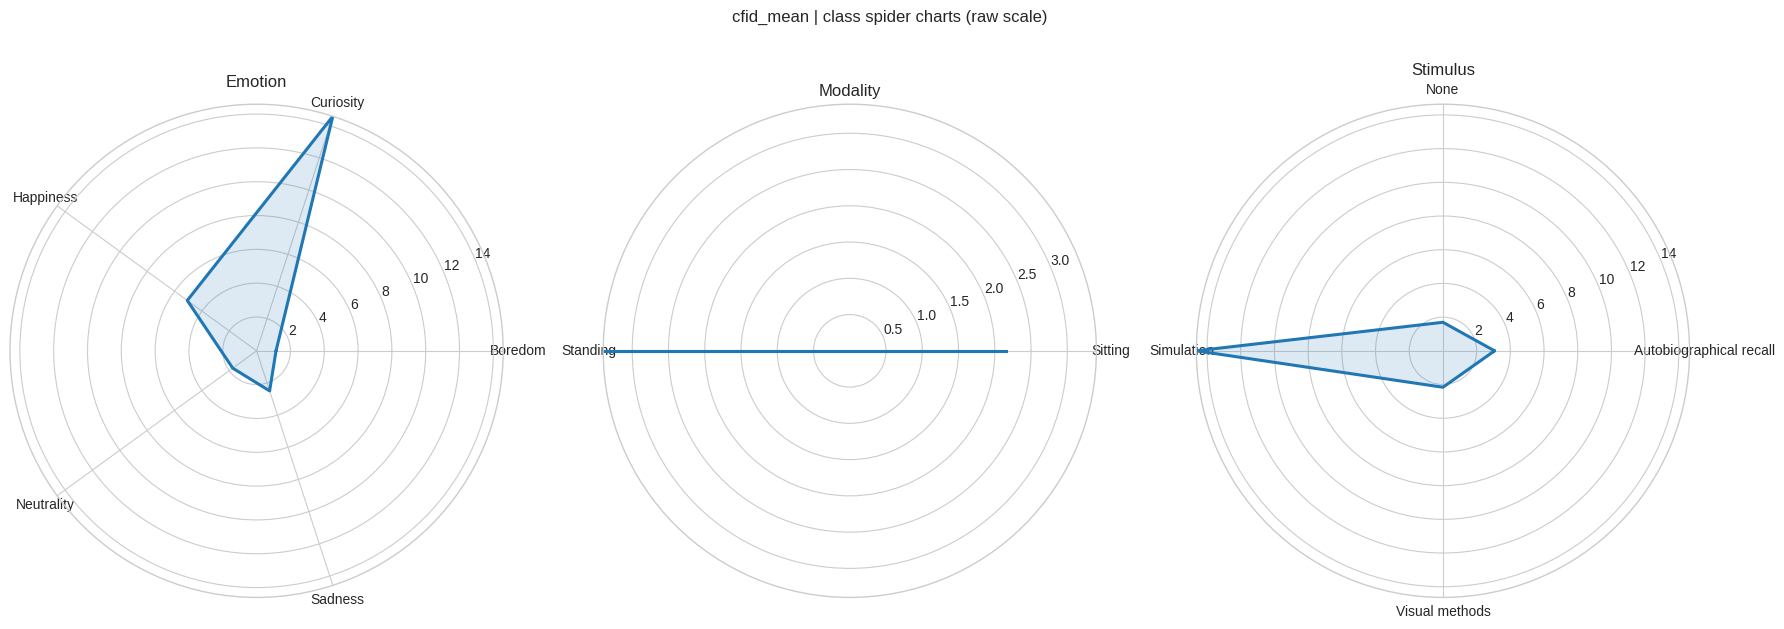

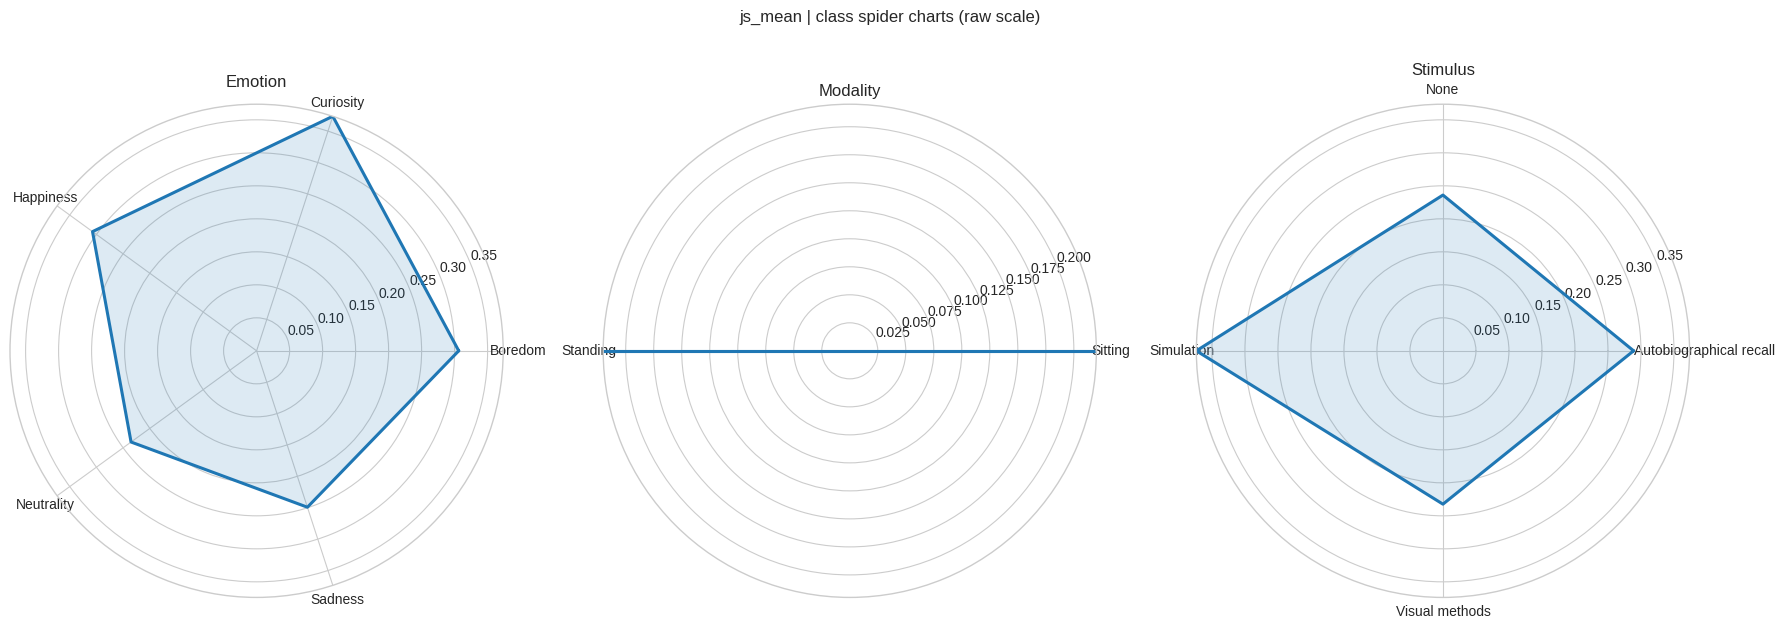

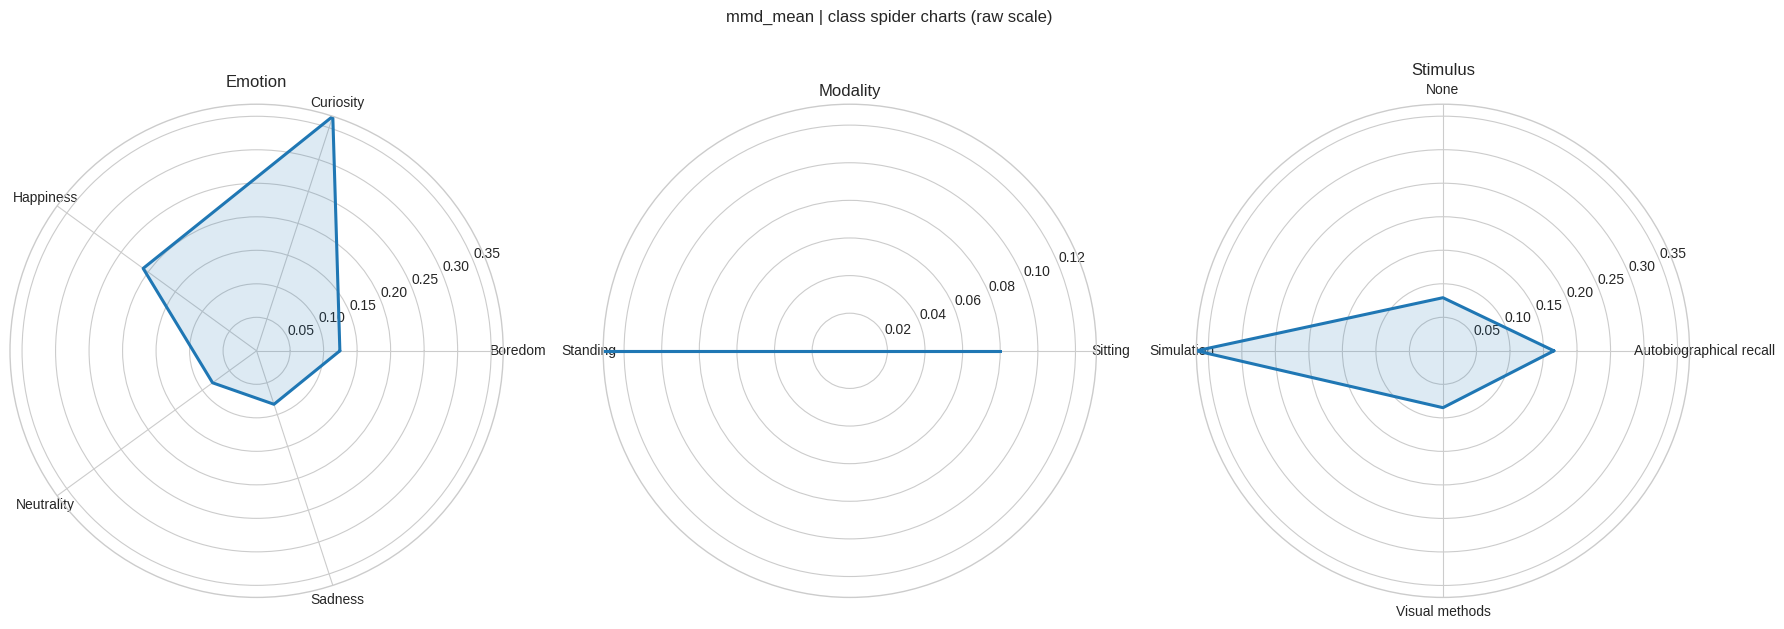

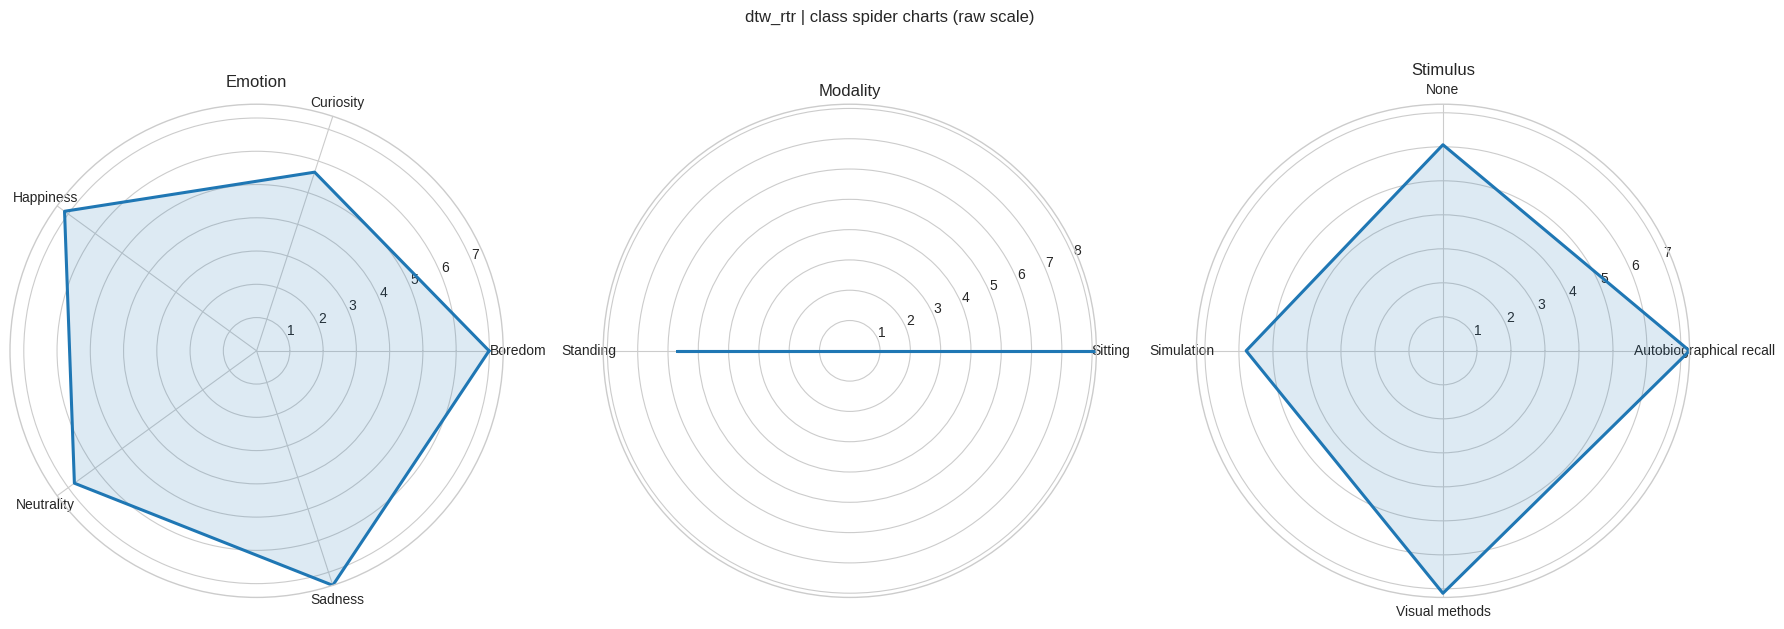

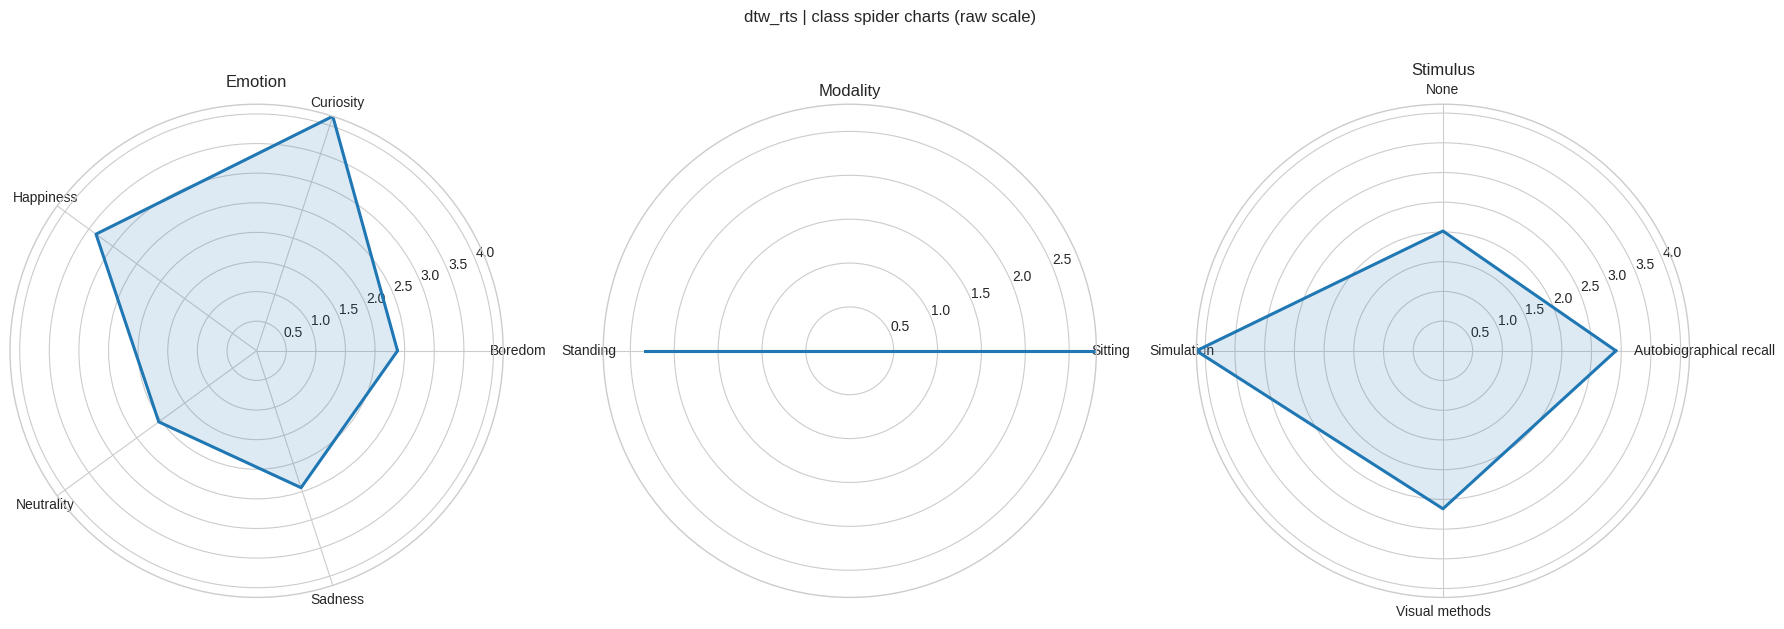

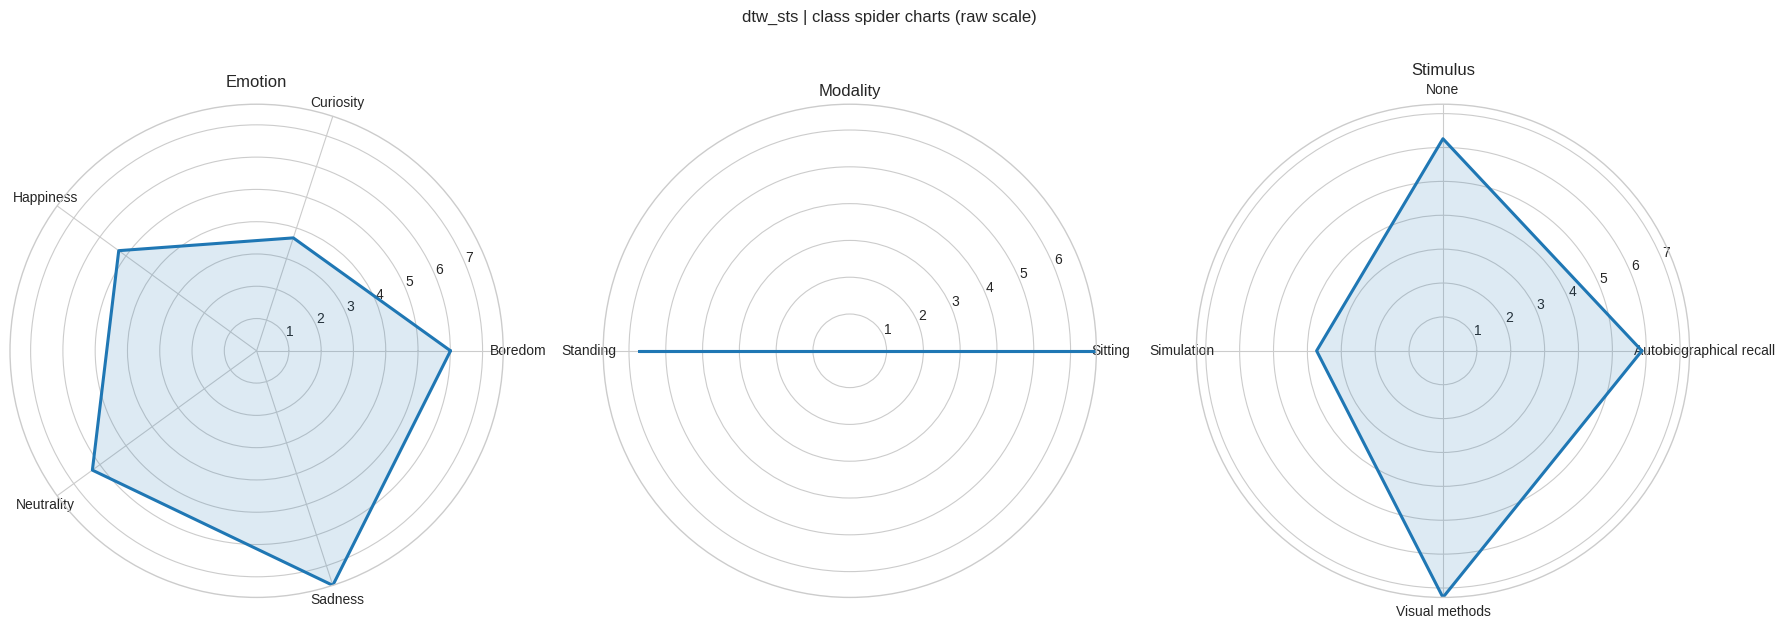

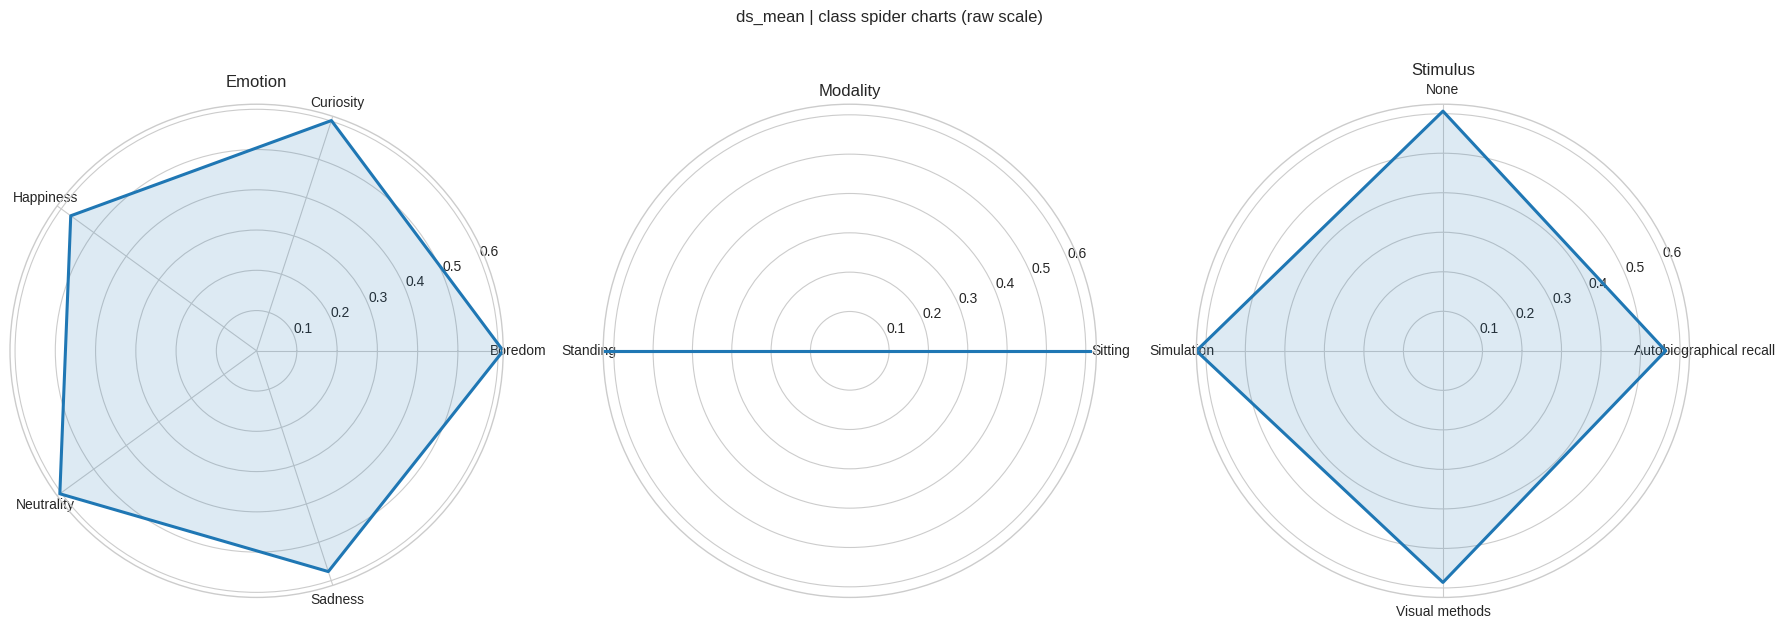

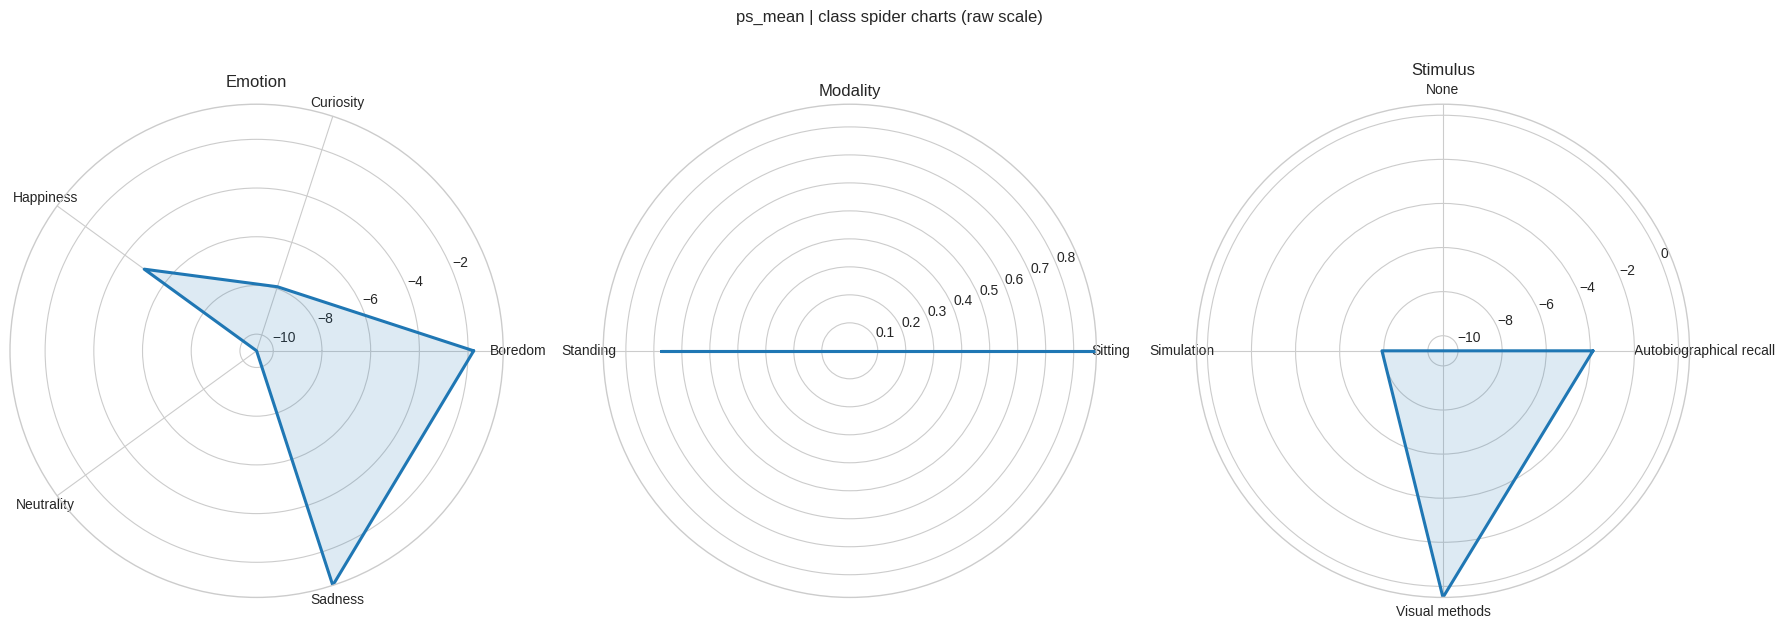

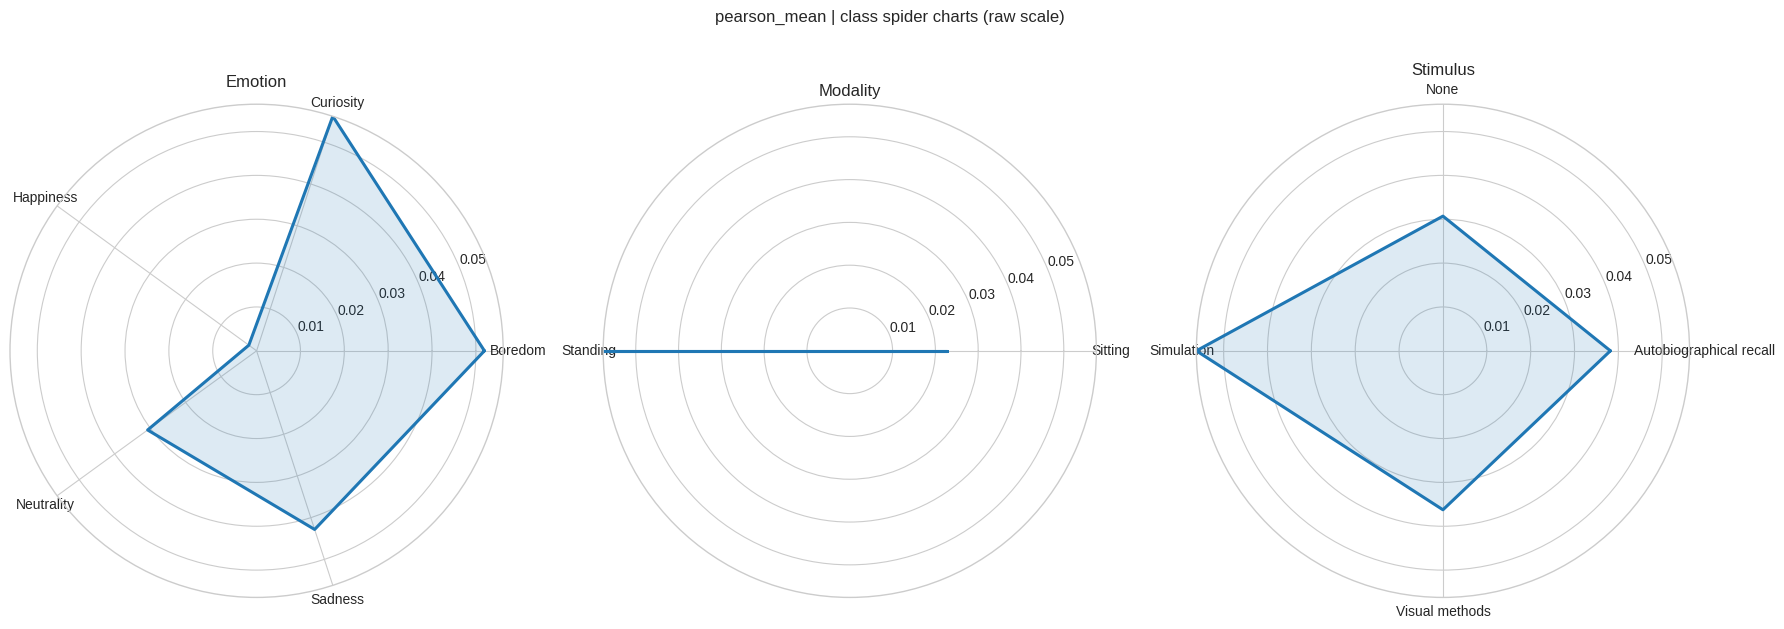

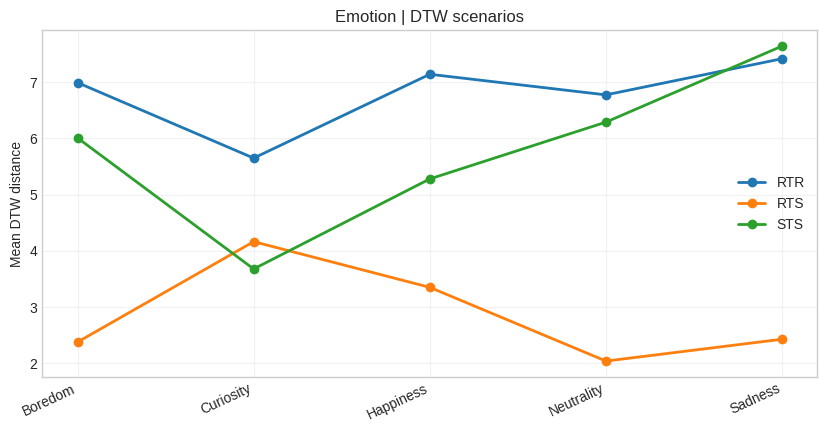

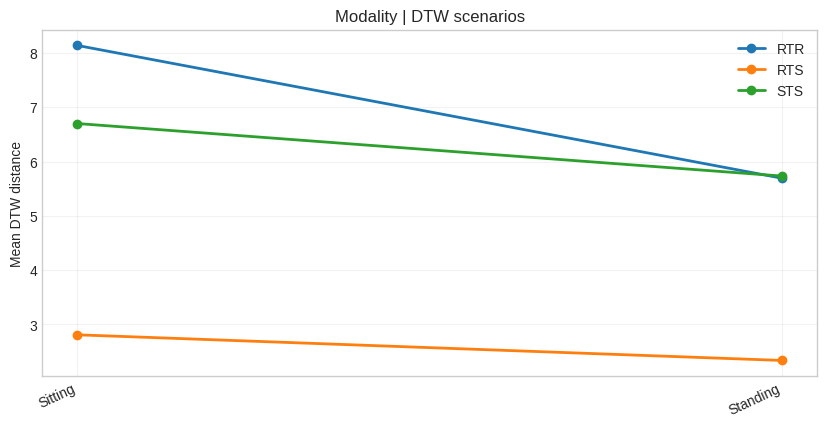

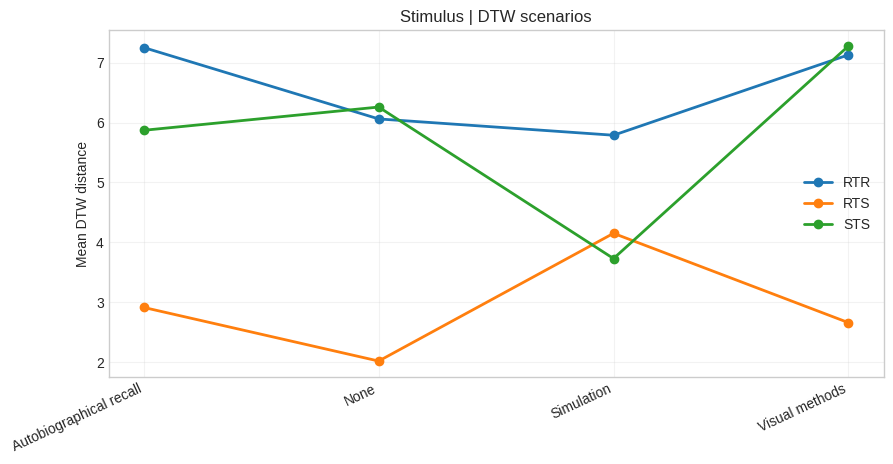

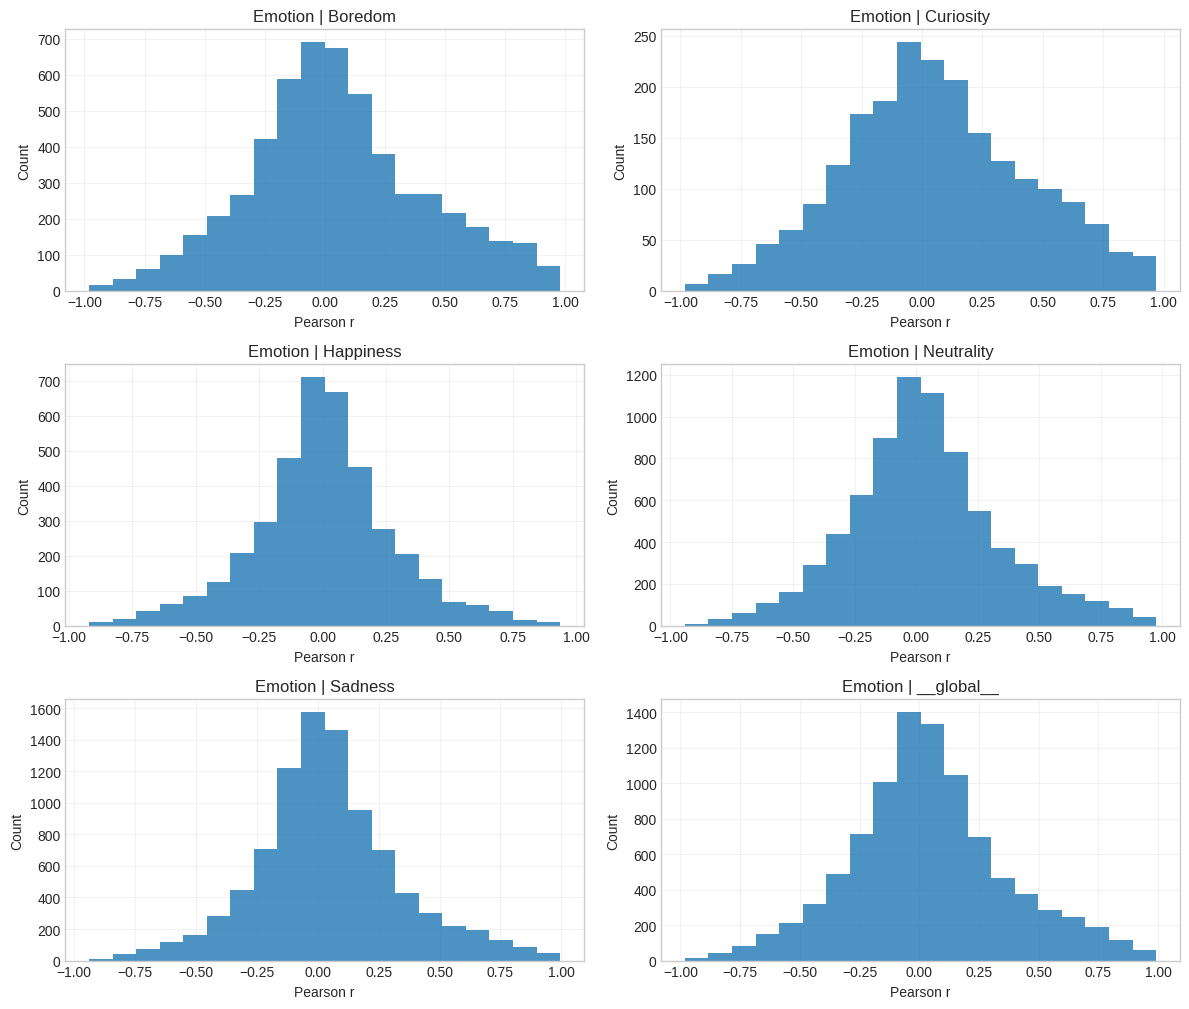

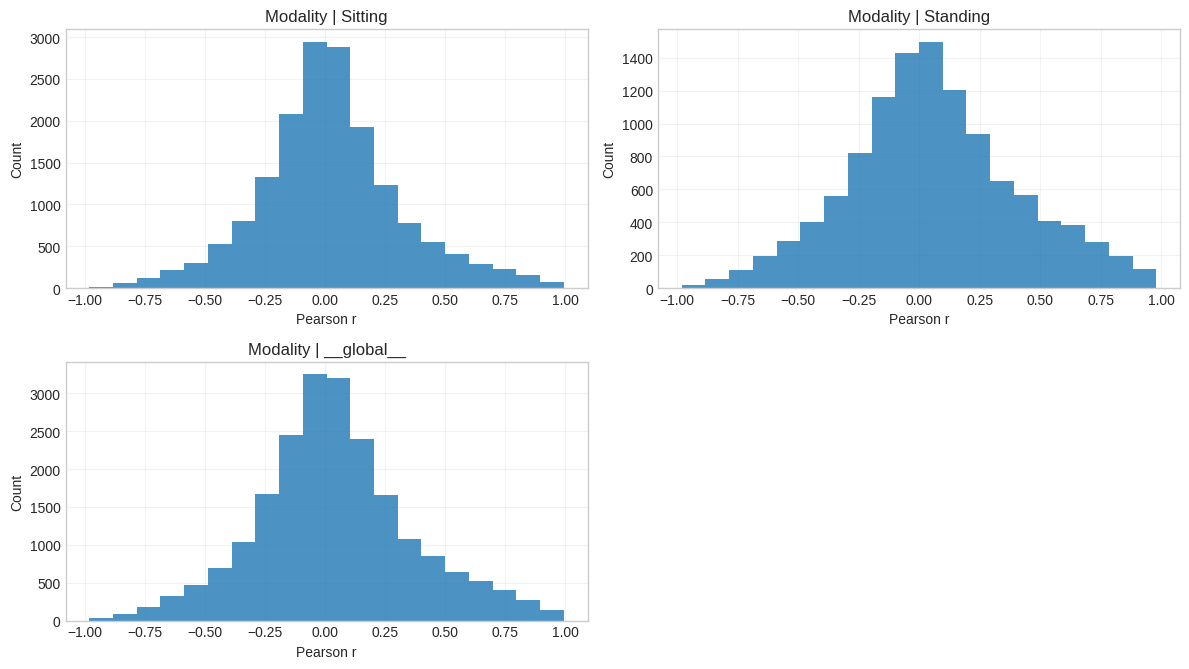

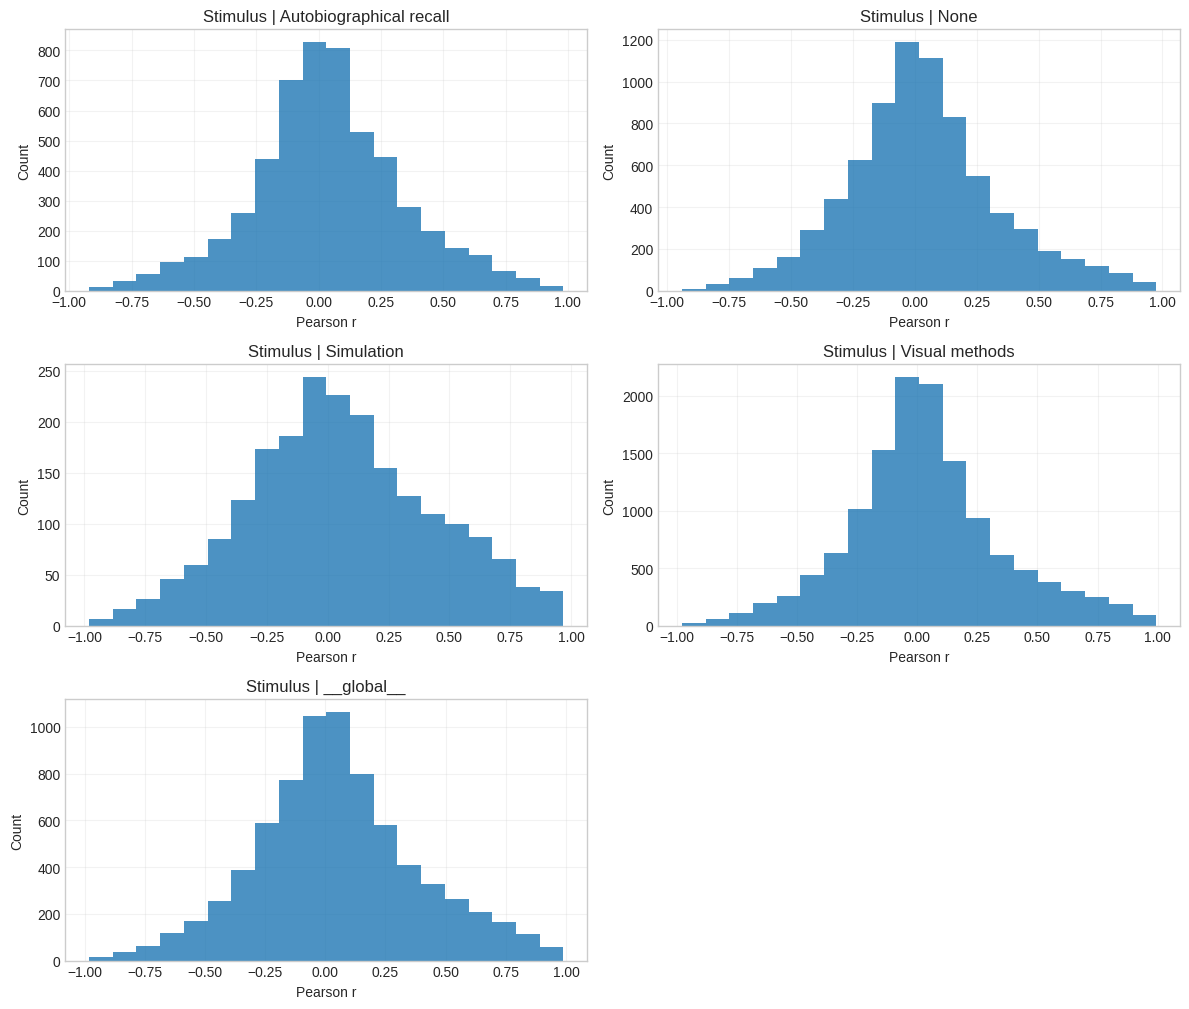

In [24]:
RESULT_REAL = run_pose_experiment("real_pose", CAPTURES_REAL)

---
## Experiment 2 — Synthetic pose (Kimodo)

Uses `exp_synthetic_pose/virtual_imu_manifest.jsonl`. Each sample is a 5-second Kimodo window;
the real IMU comes from the corresponding reference clip for comparison.

### synthetic_pose — running protocol on 3582 captures

Epoch #0: loss=6.238327923105724


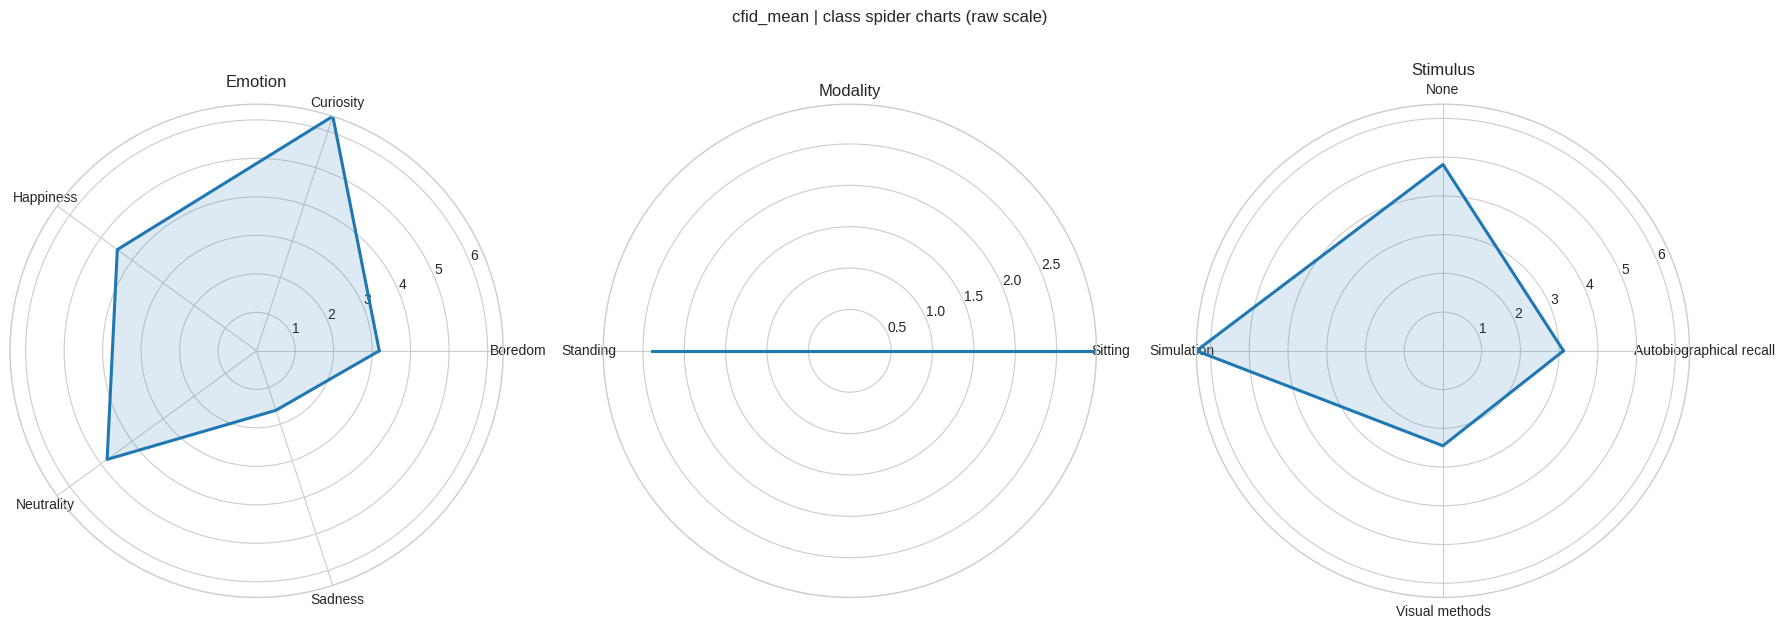

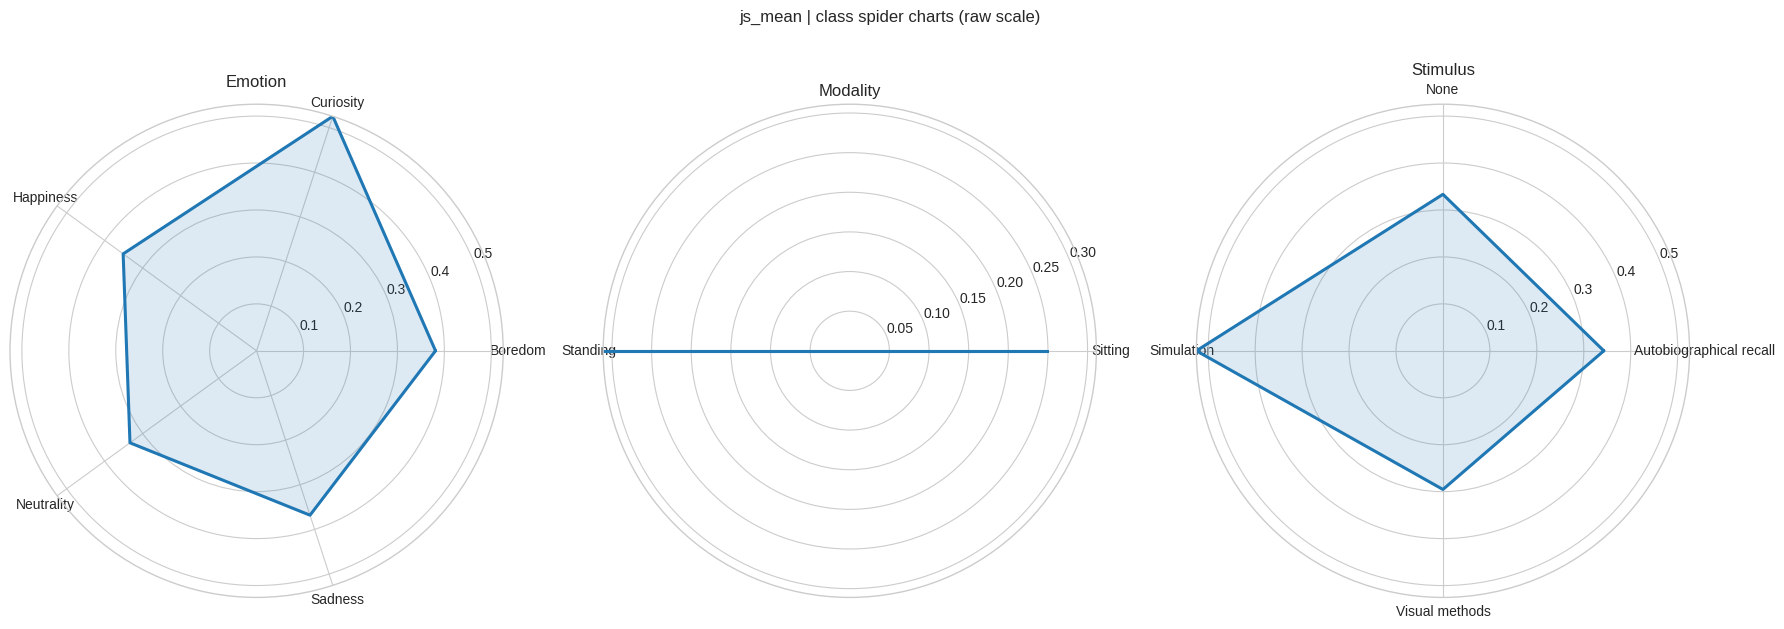

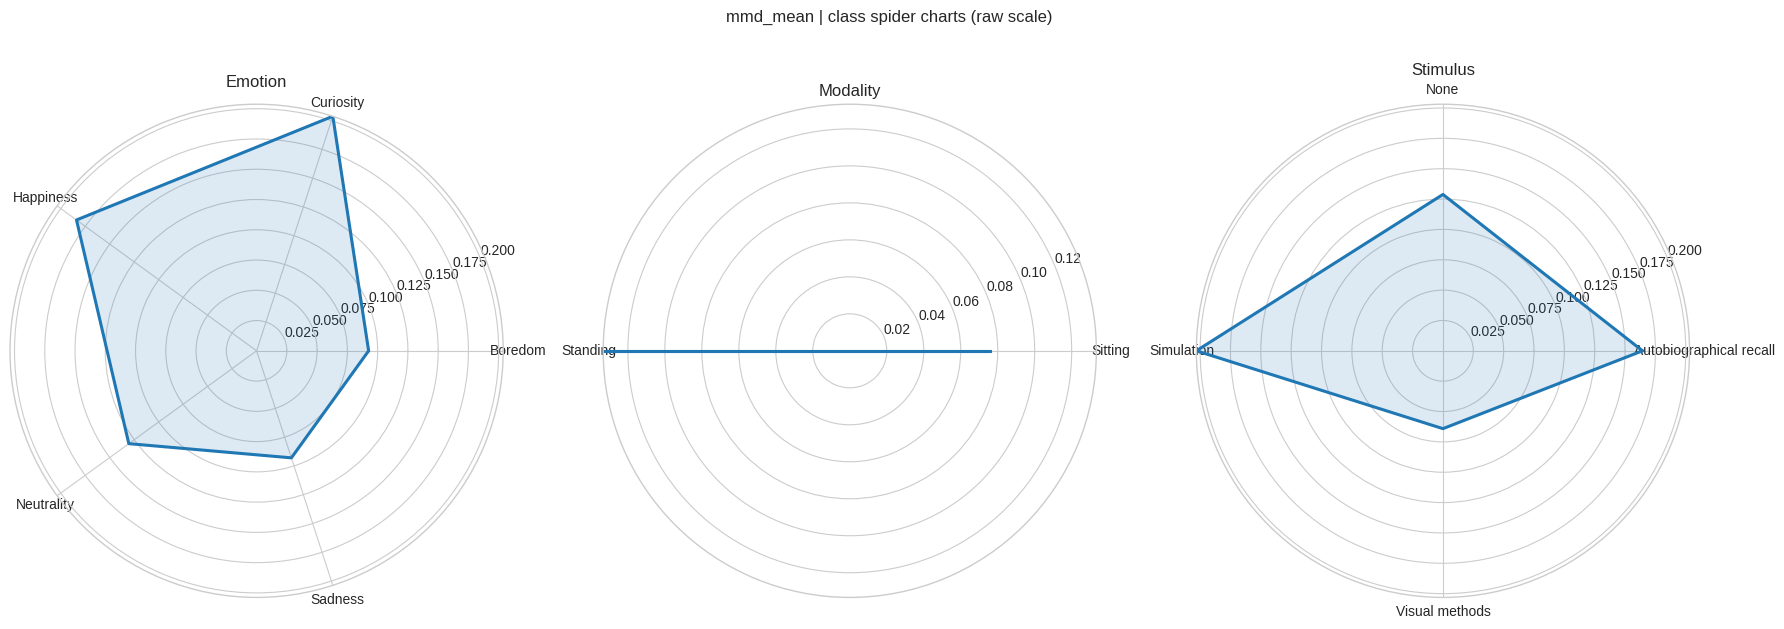

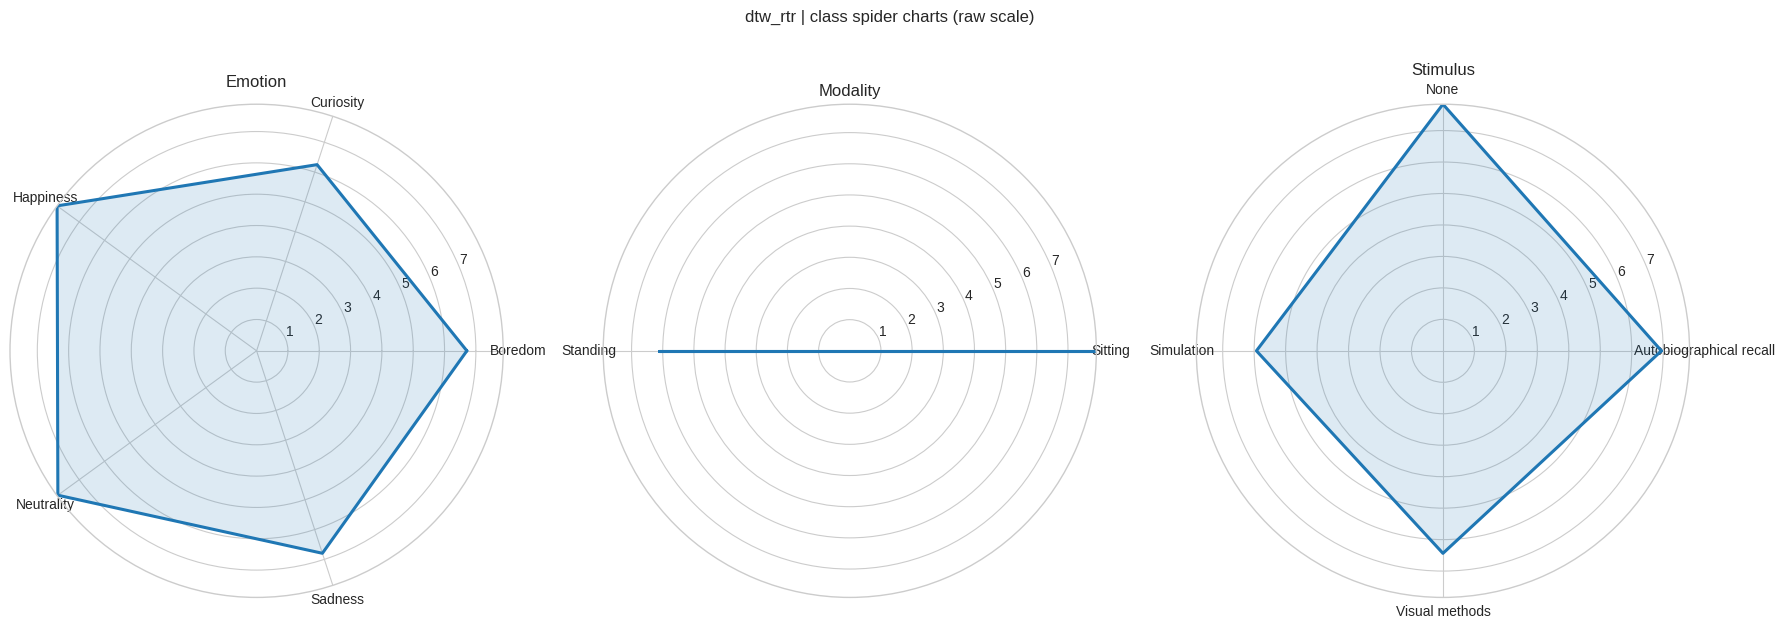

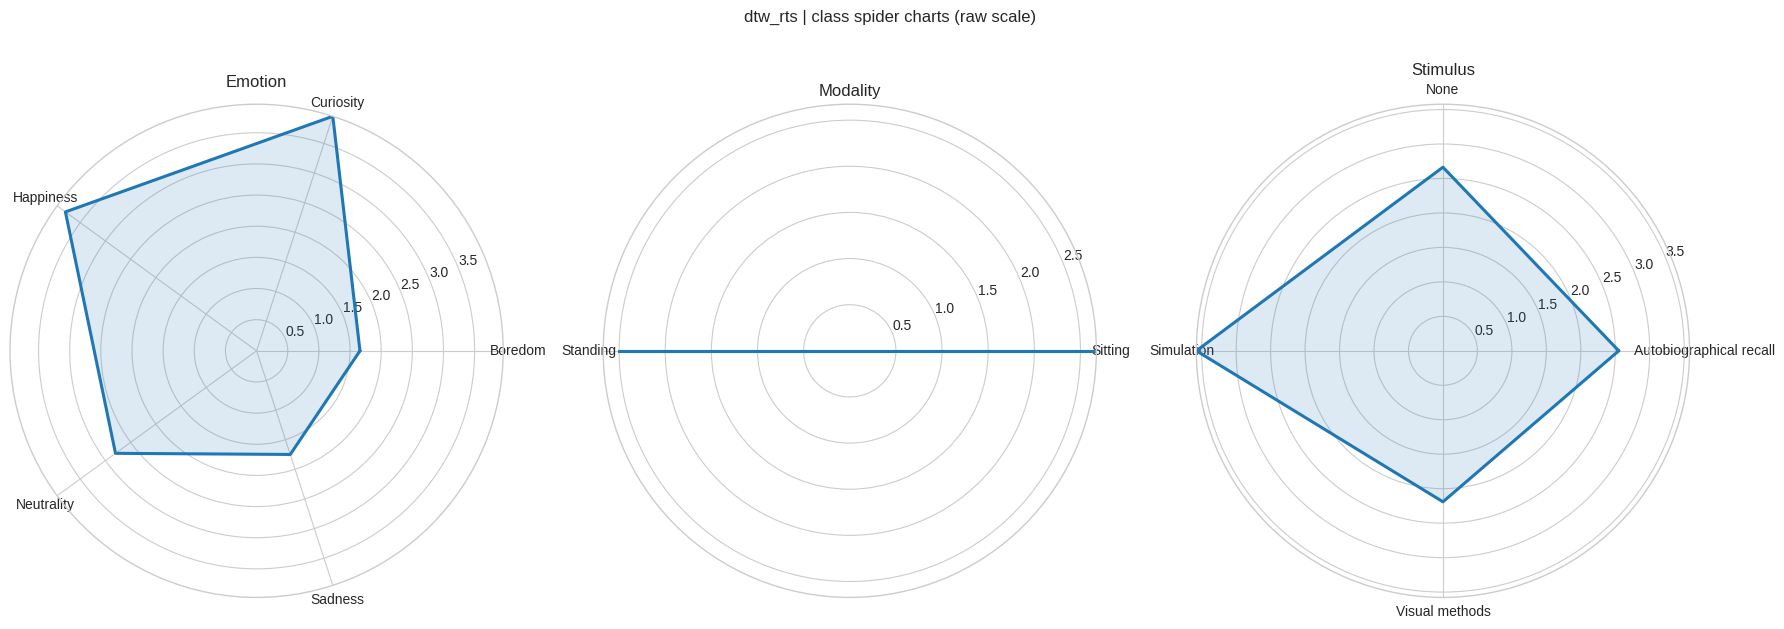

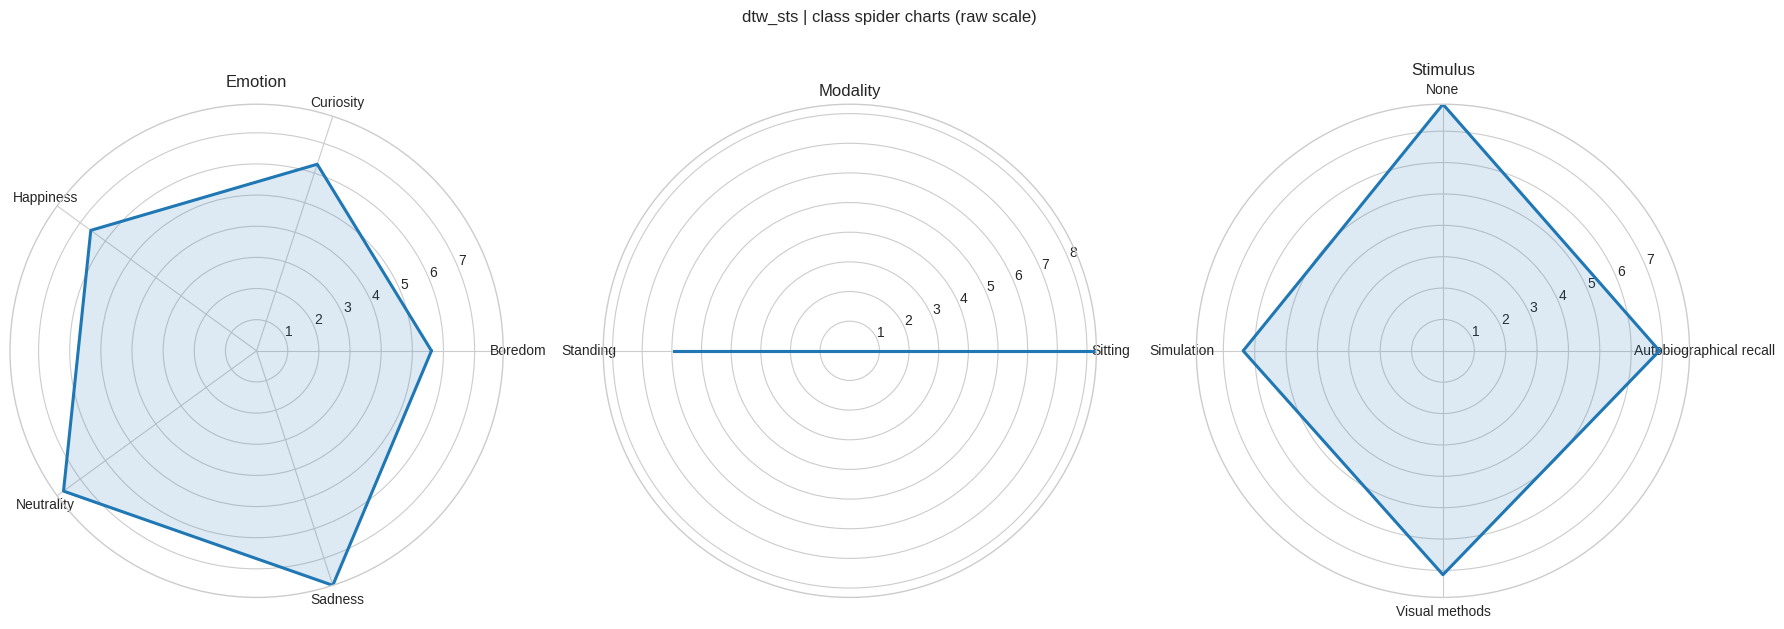

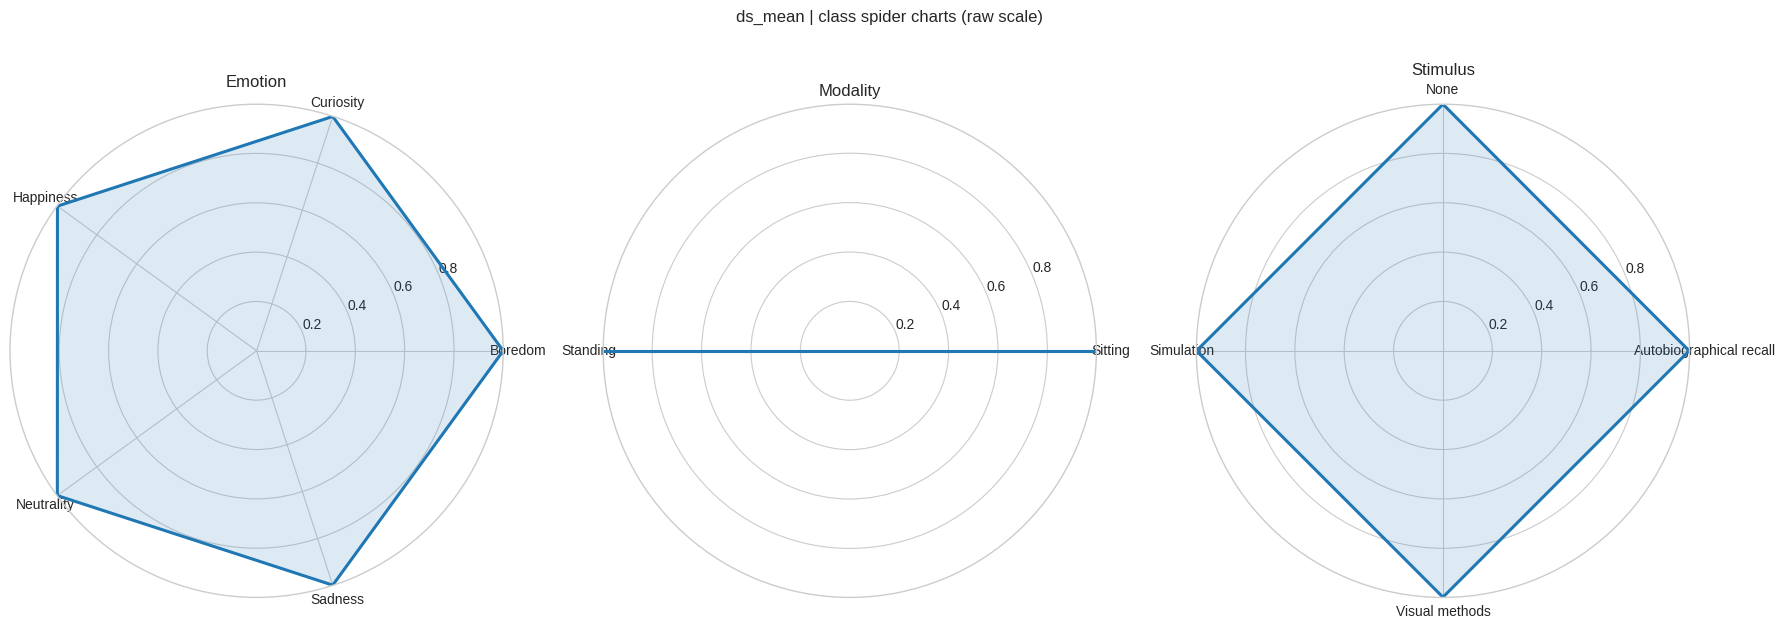

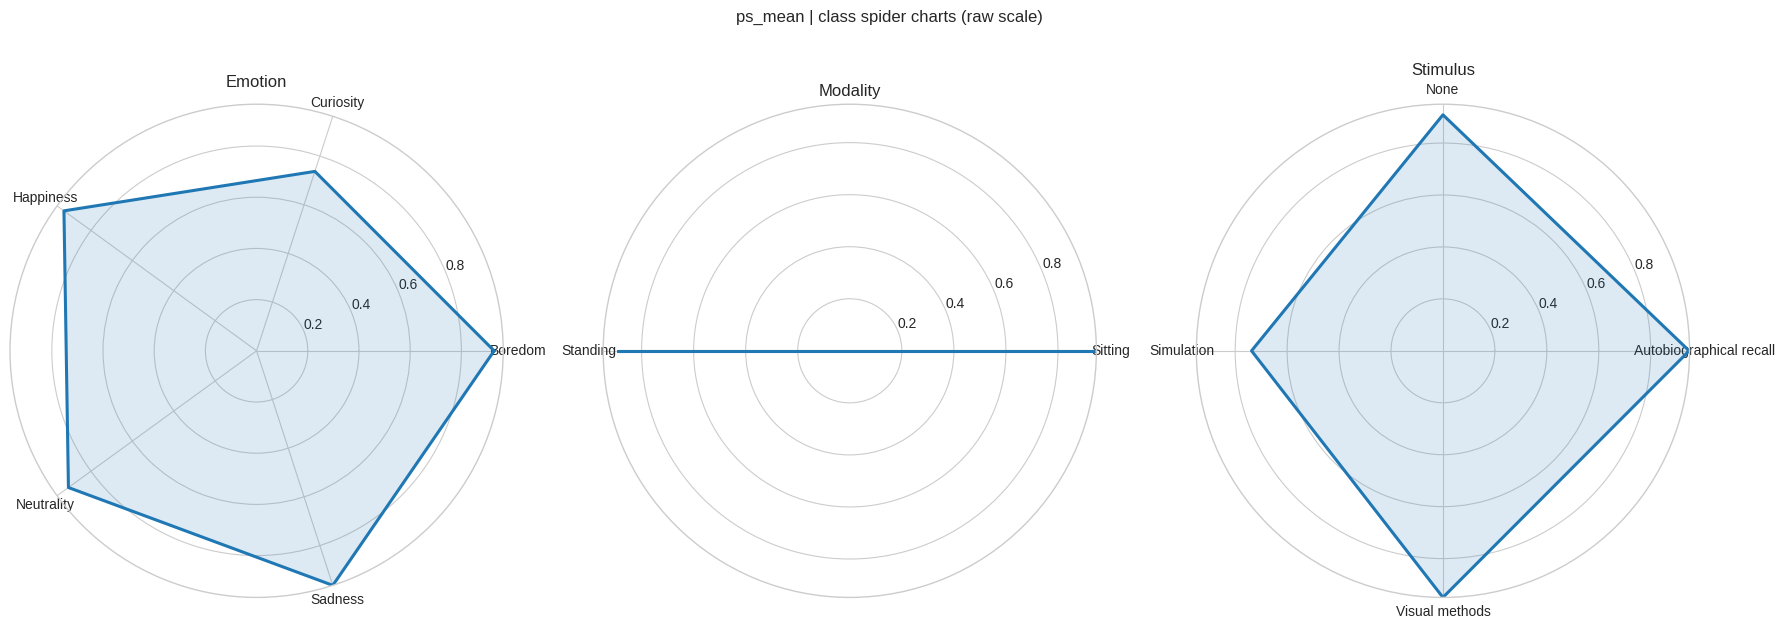

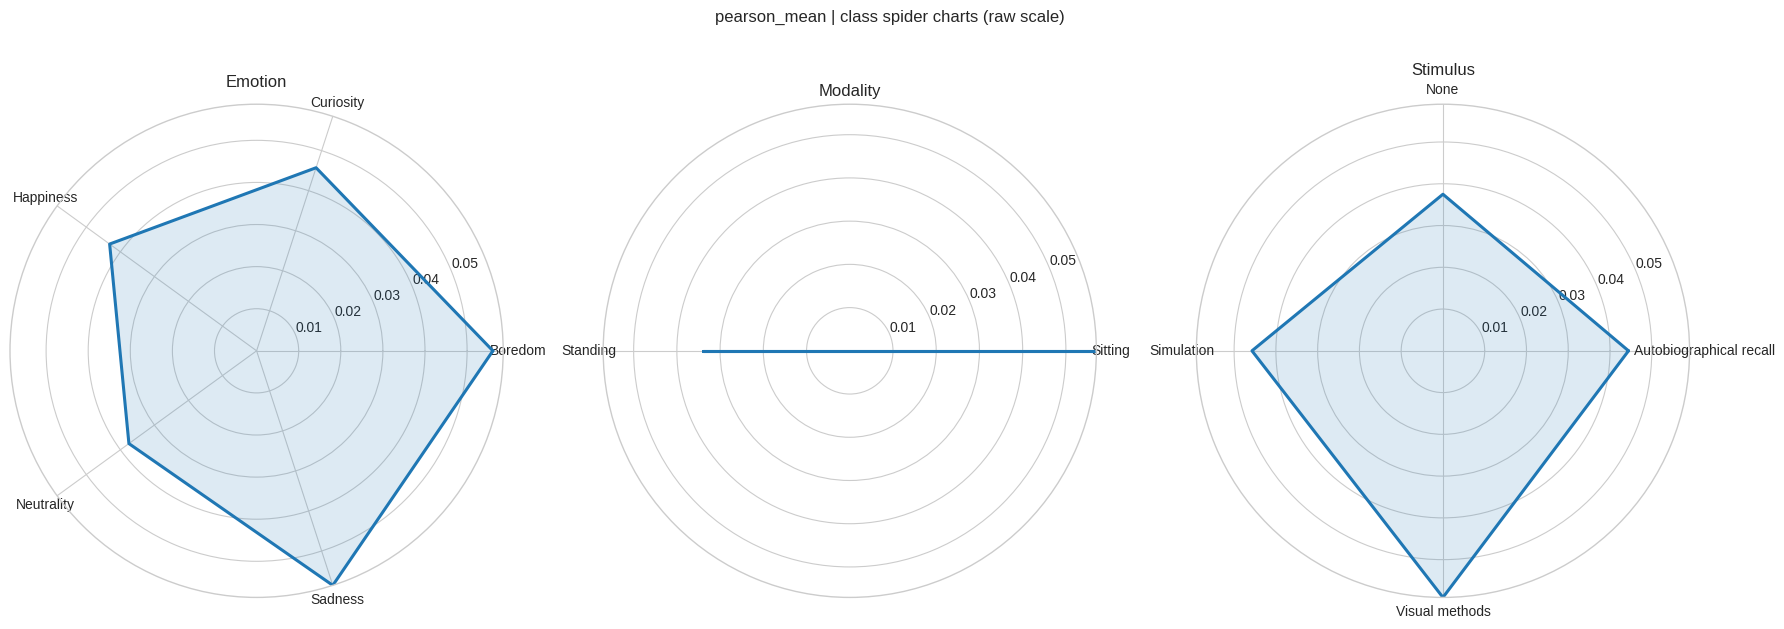

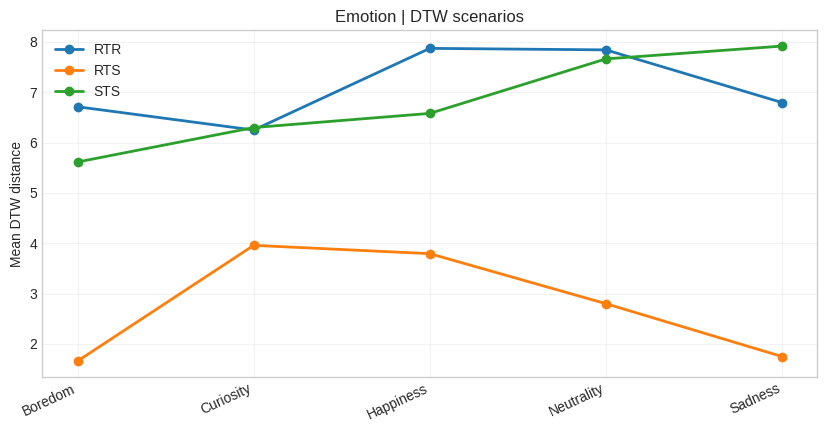

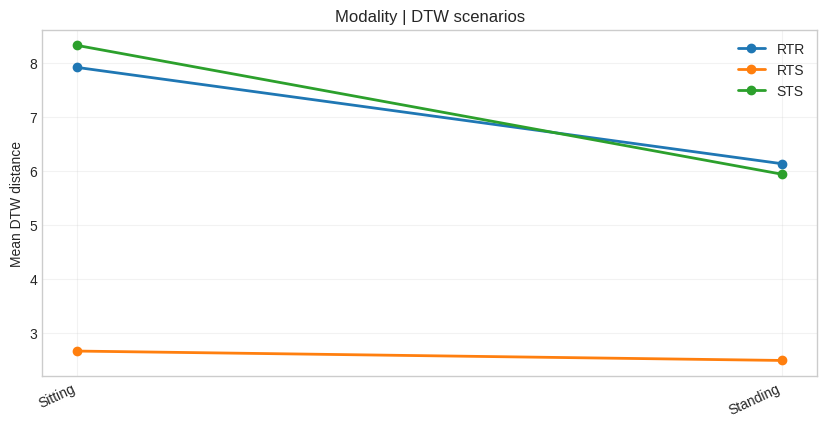

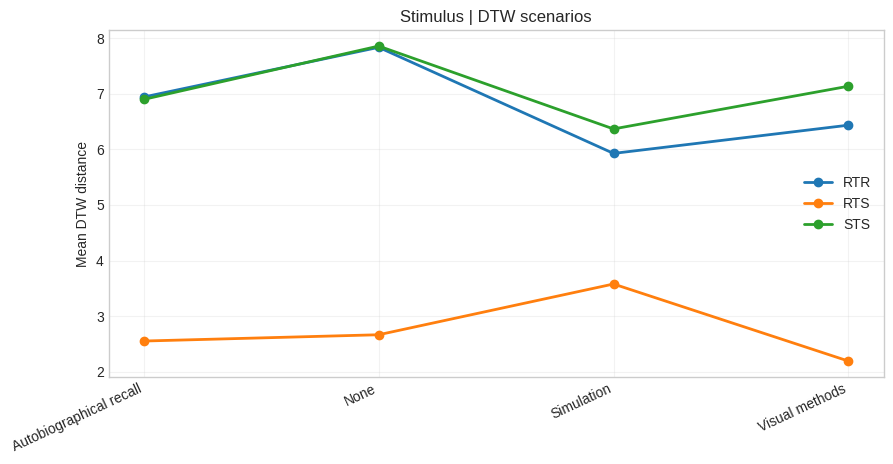

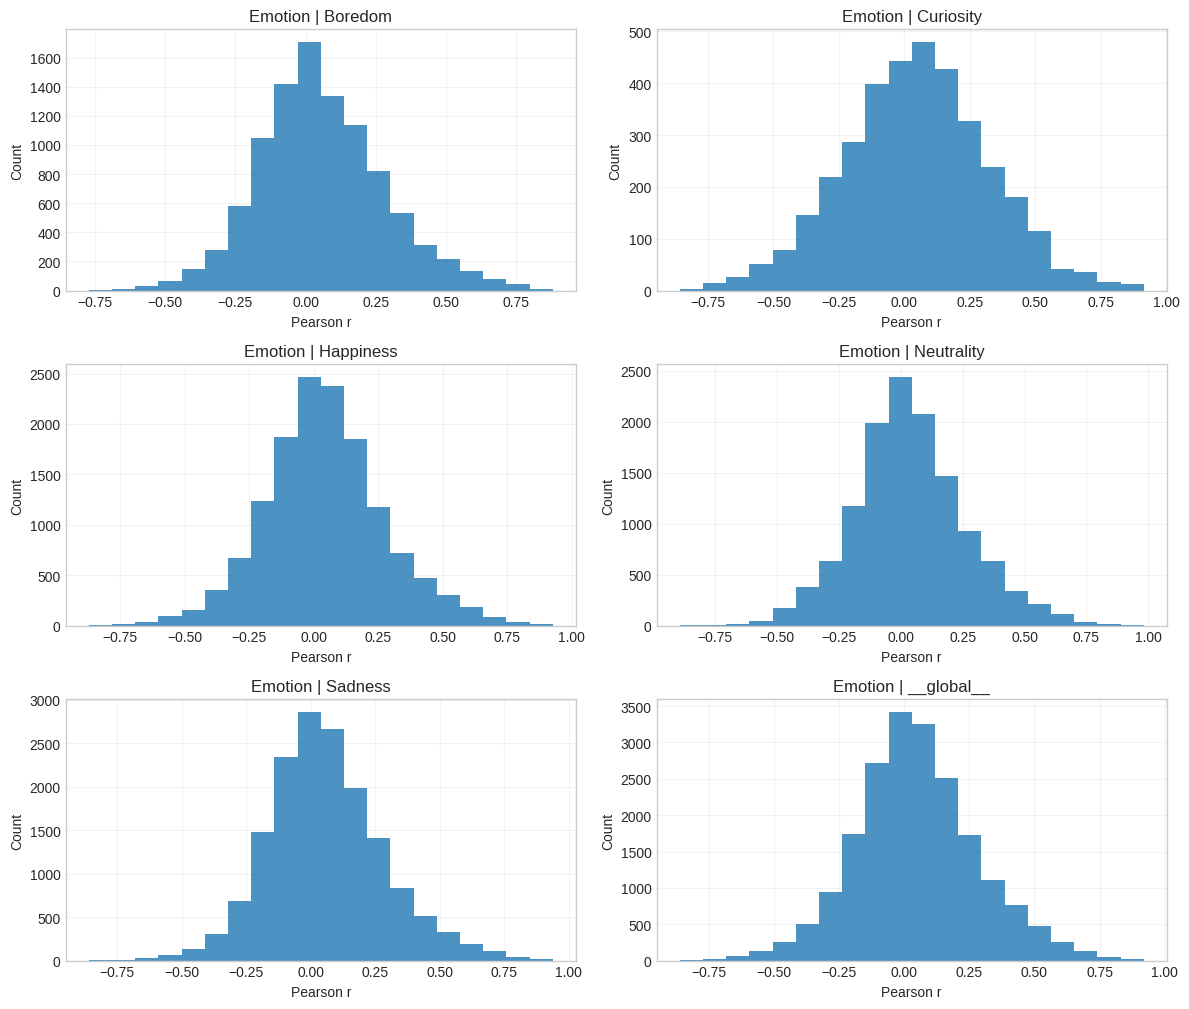

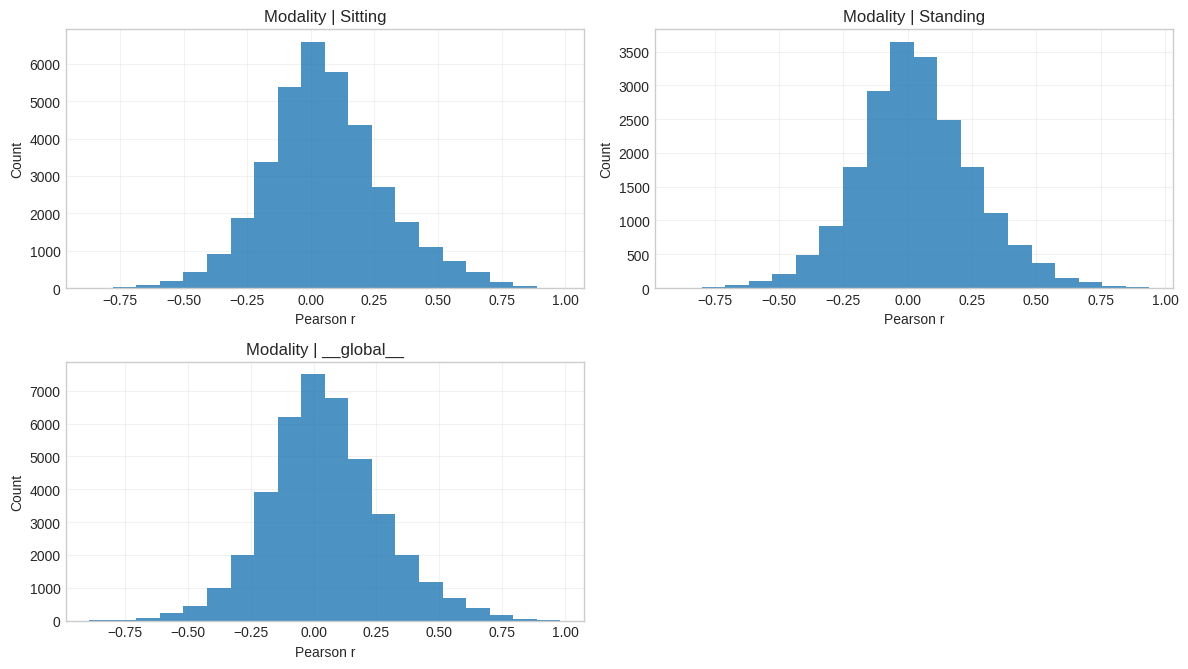

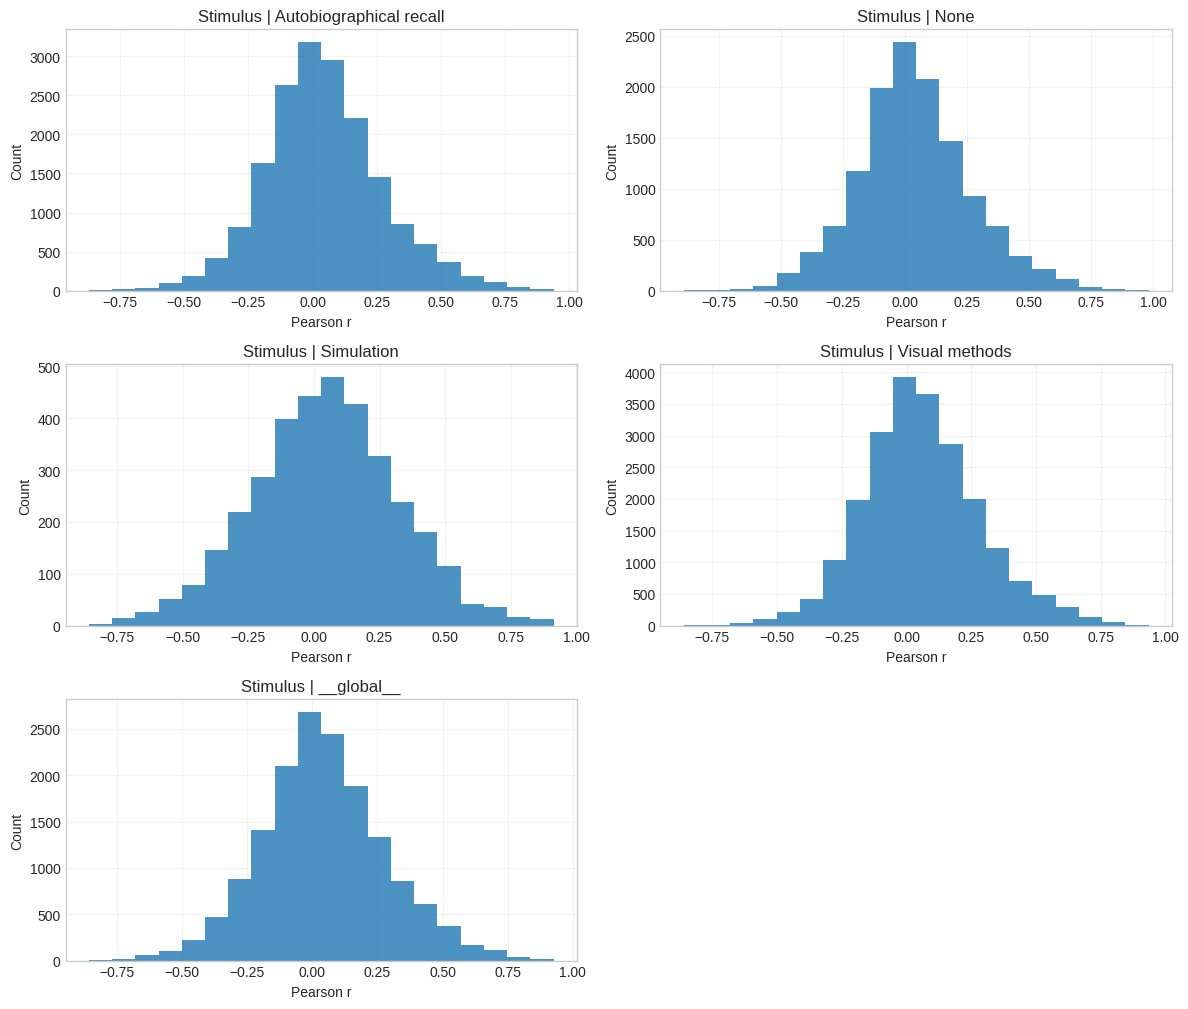

In [25]:
RESULT_SYNTHETIC = run_pose_experiment("synthetic_pose", CAPTURES_SYNTHETIC)

---
## Experiment 3 — Mixed pose (real + synthetic)

Uses `exp_mixed_pose/mixed_virtual_imu_manifest.jsonl`. Combines 87 real-pipeline entries
with 3722 Kimodo entries, each paired with the corresponding real IMU.

### mixed_pose — running protocol on 3665 captures

Epoch #0: loss=3.6996032893657684


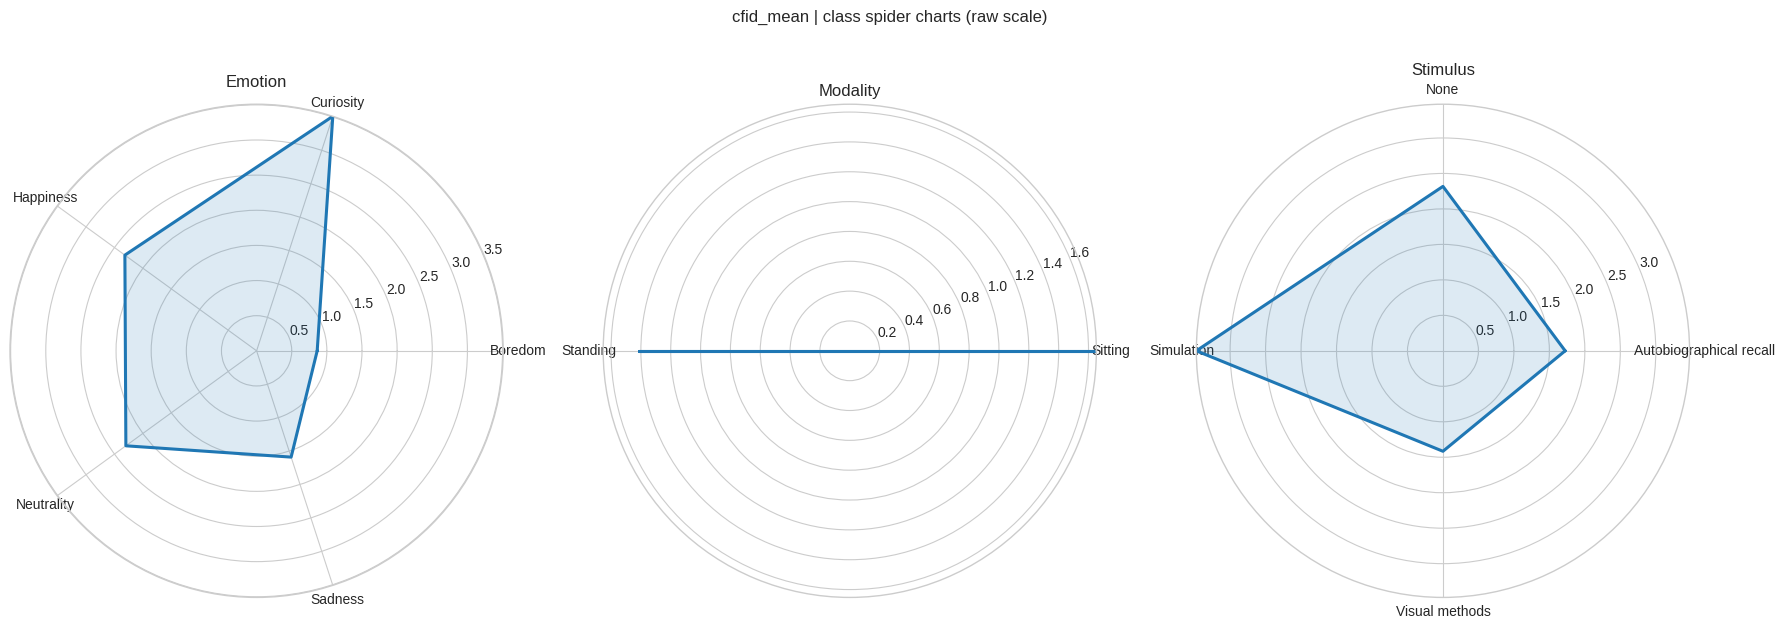

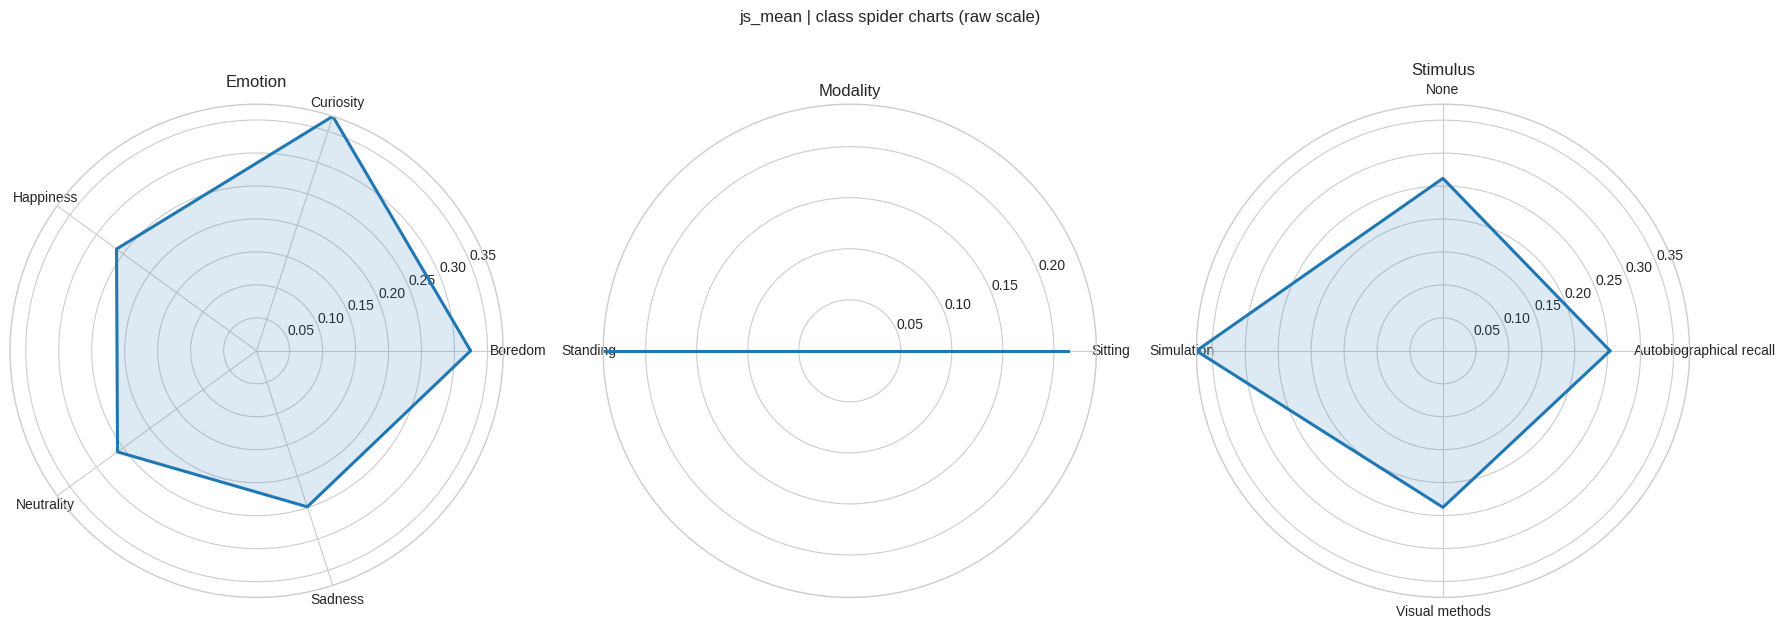

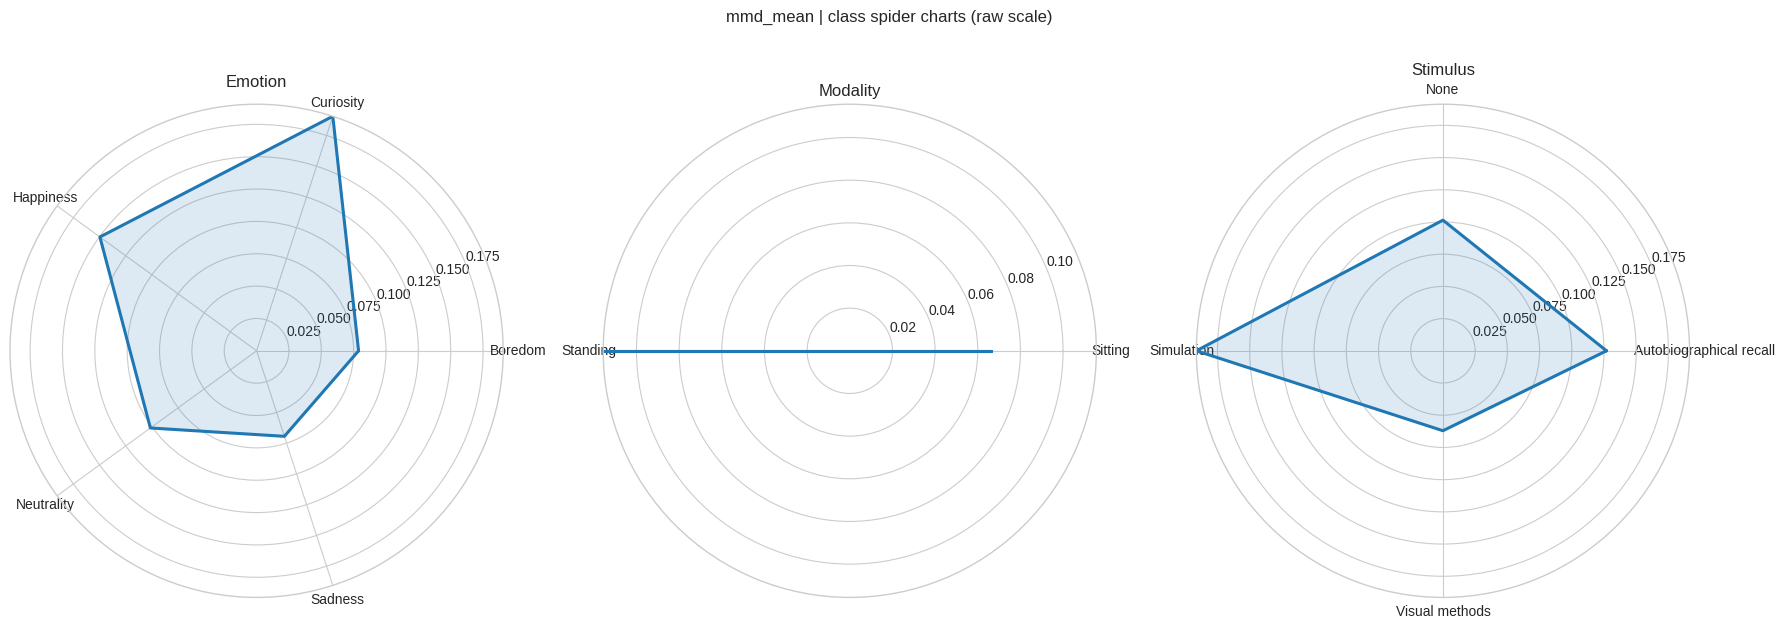

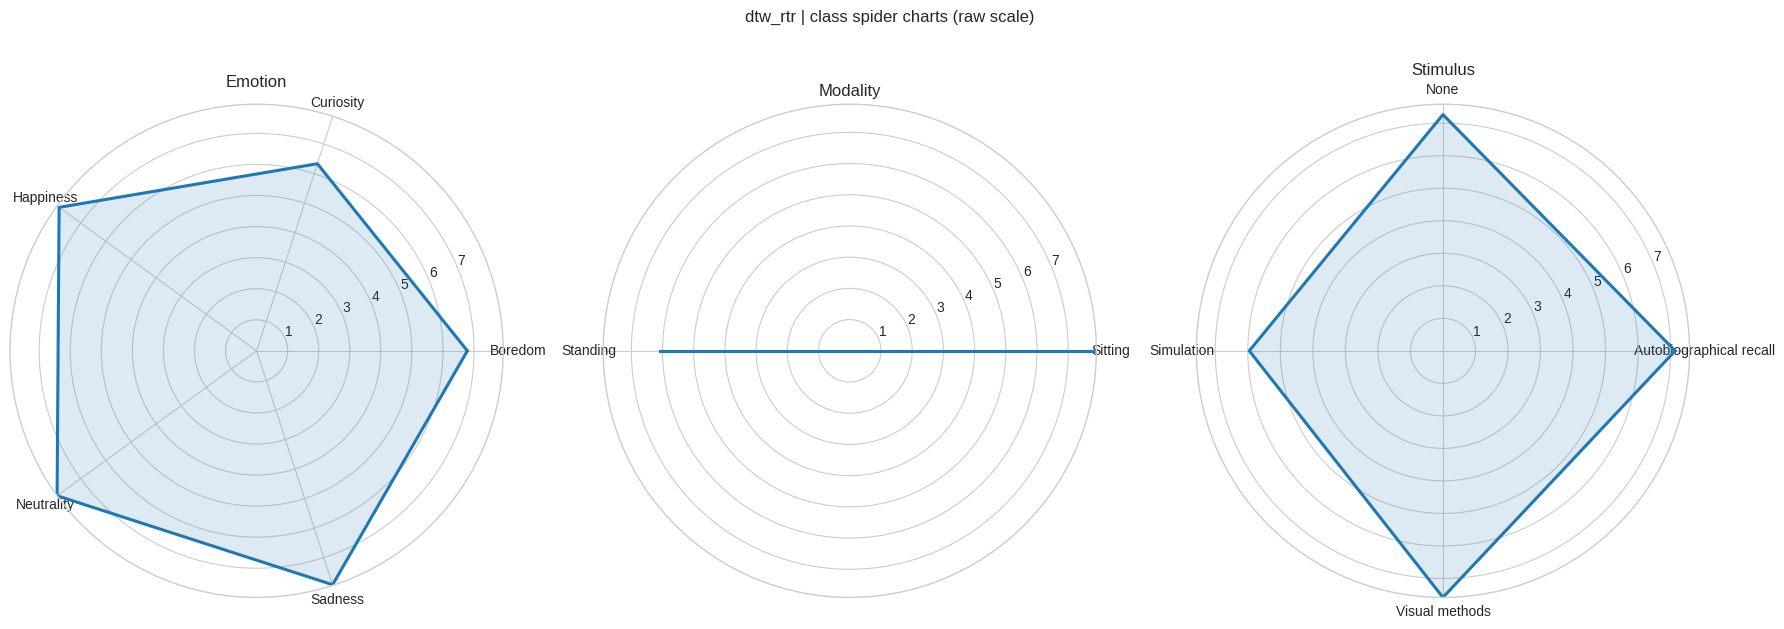

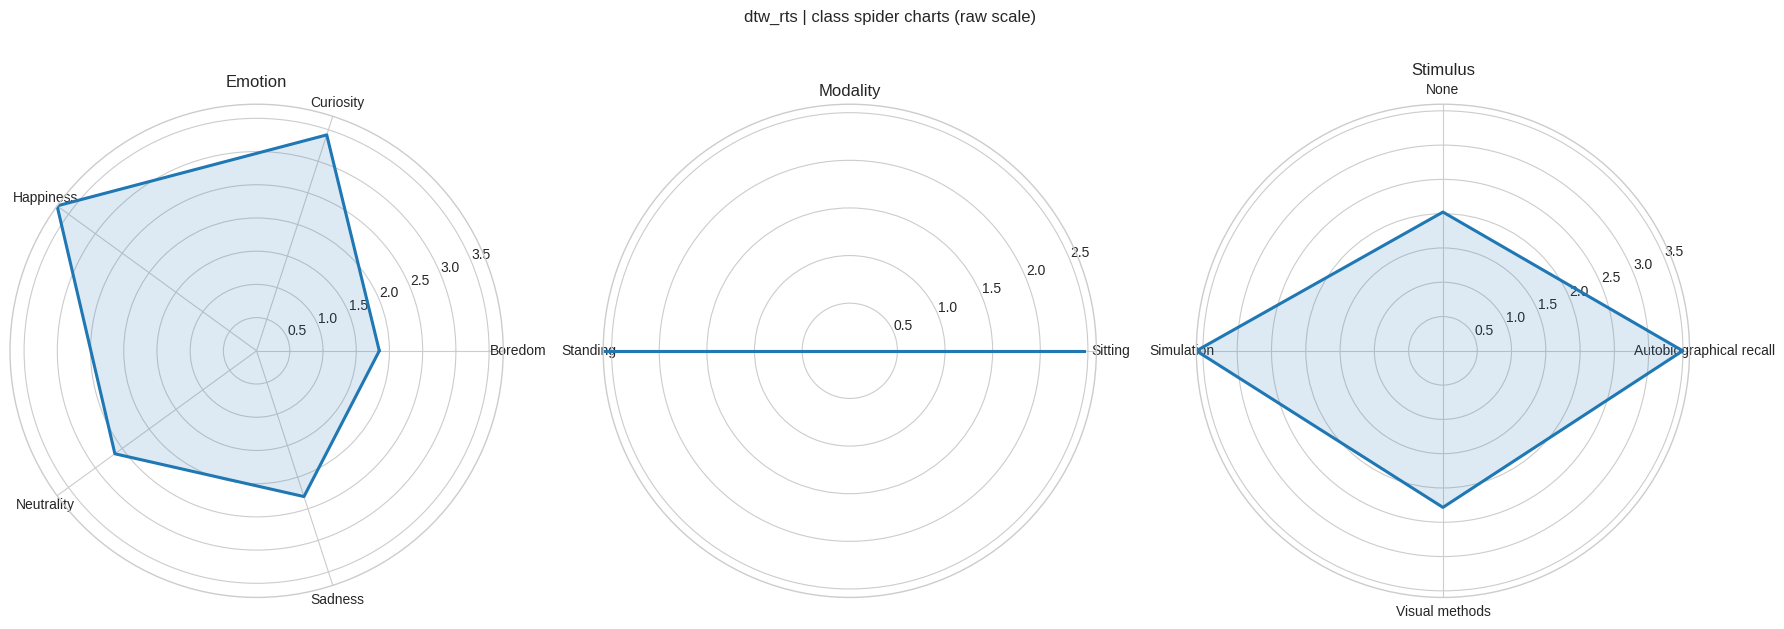

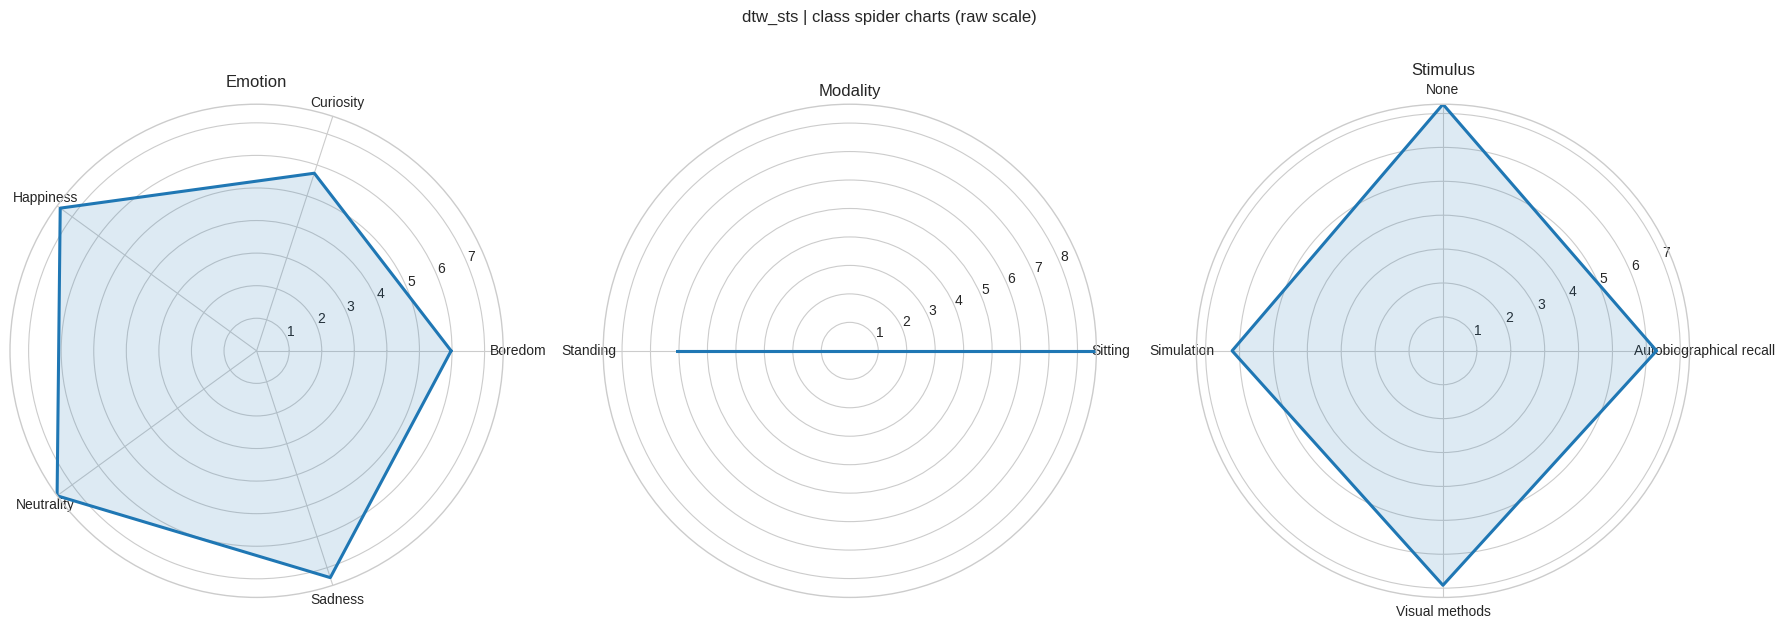

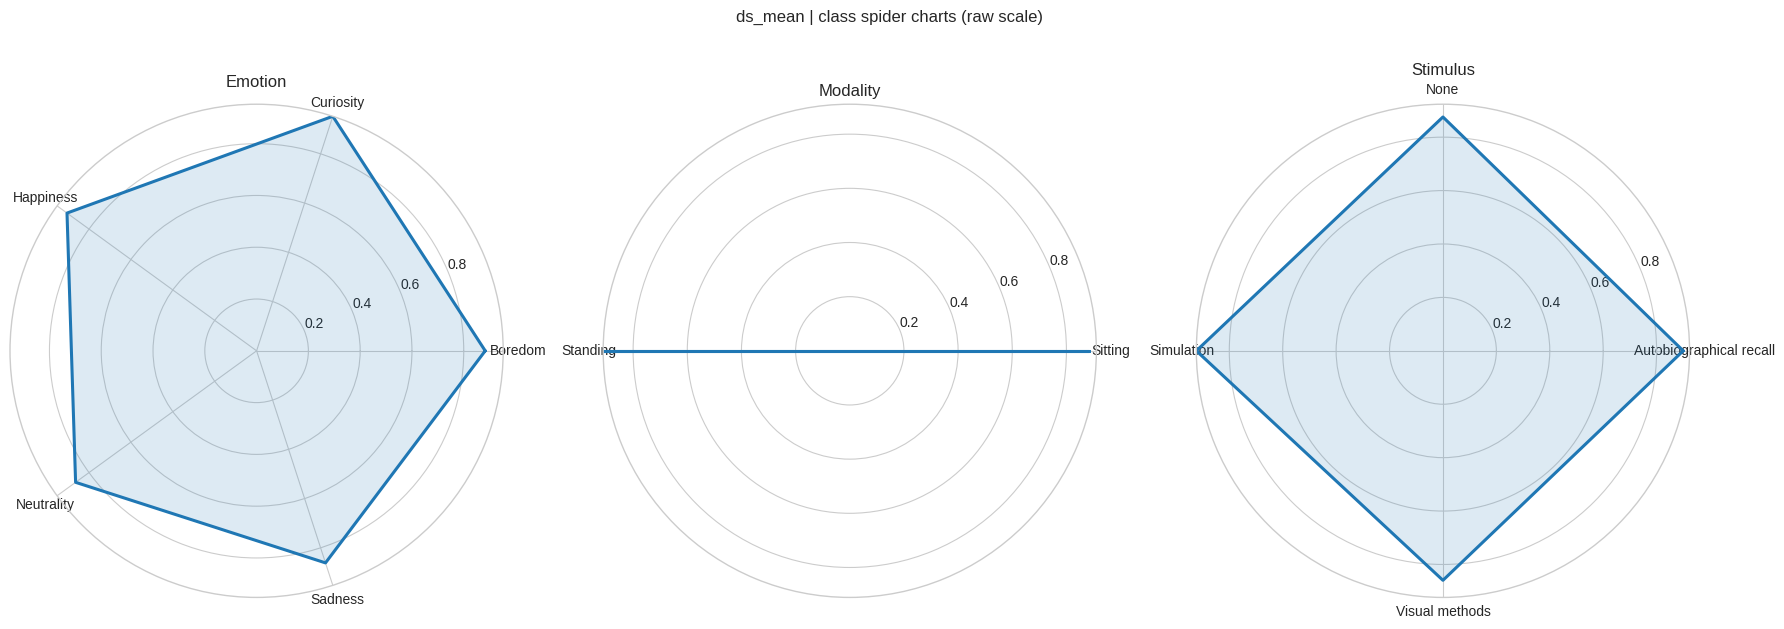

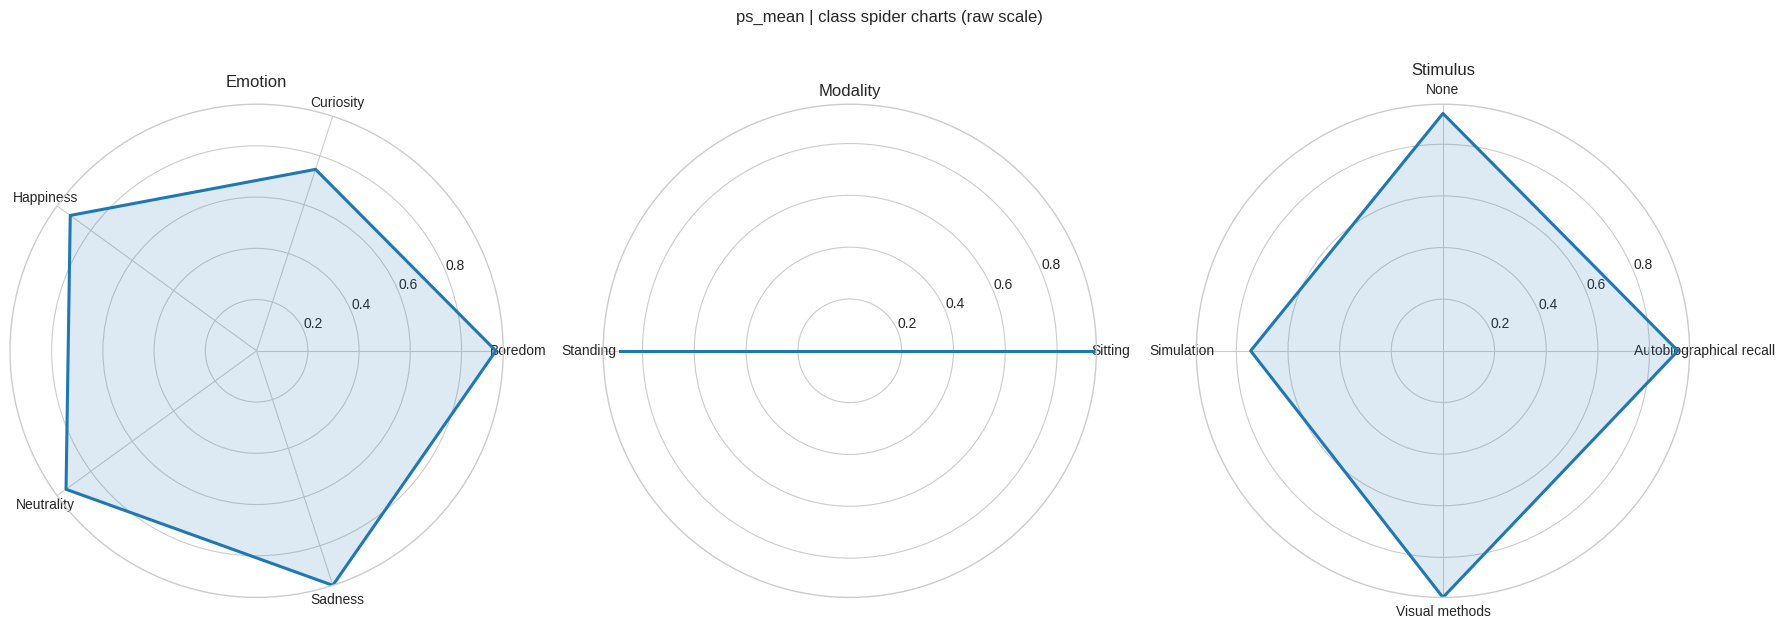

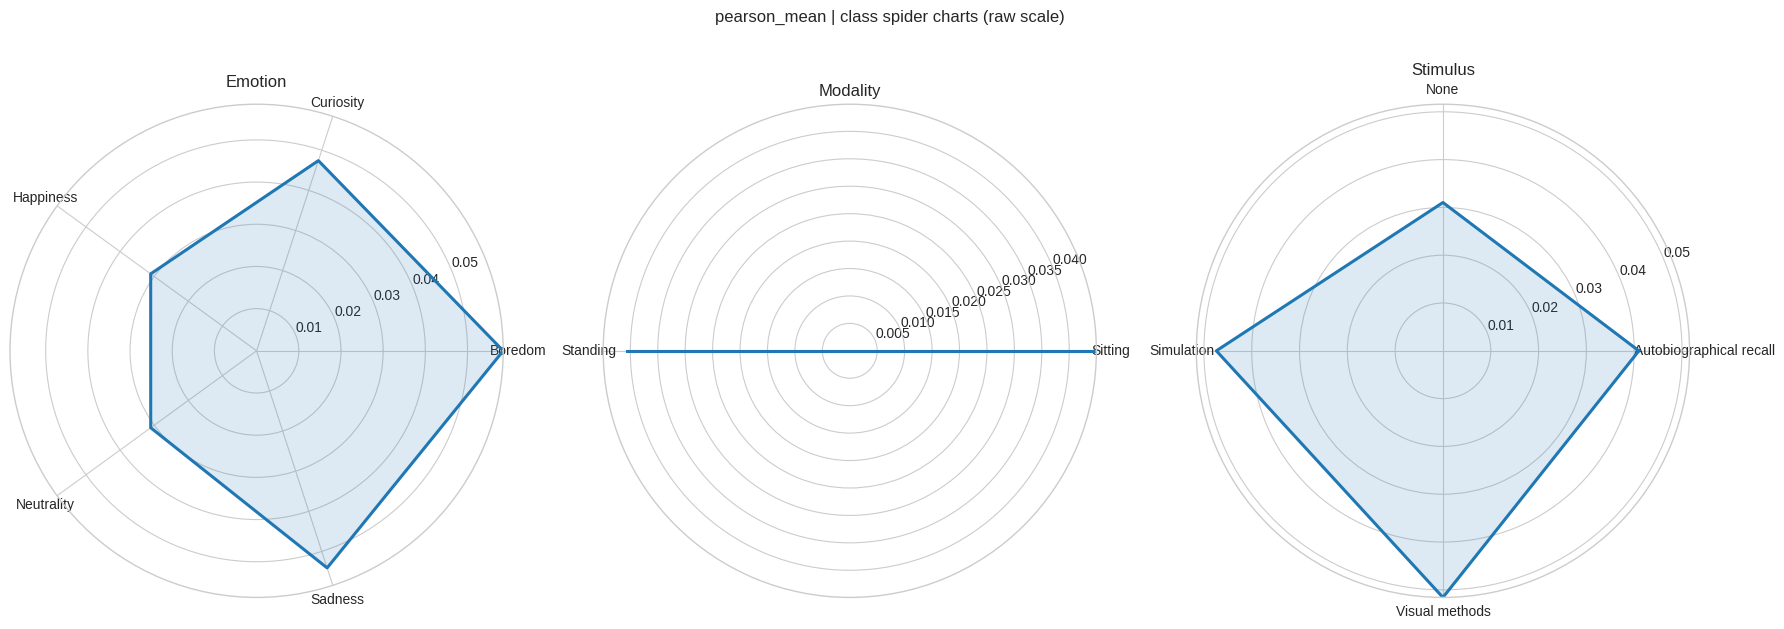

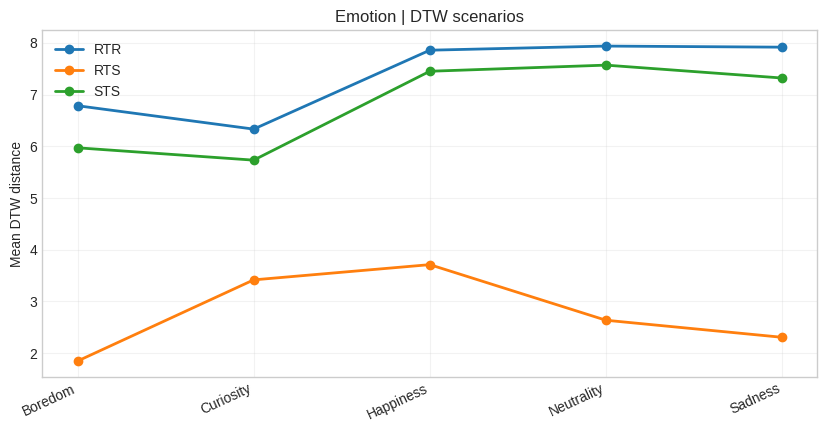

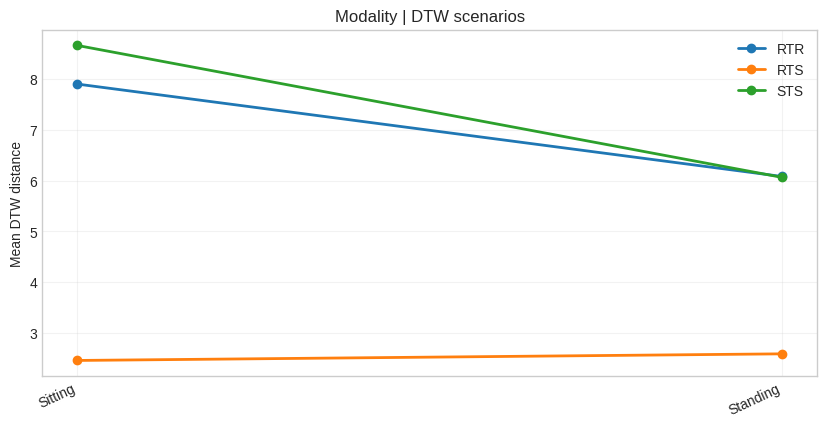

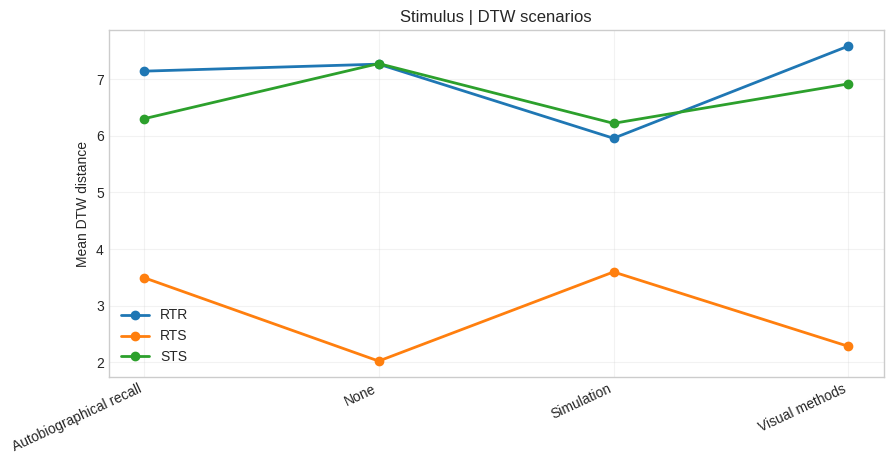

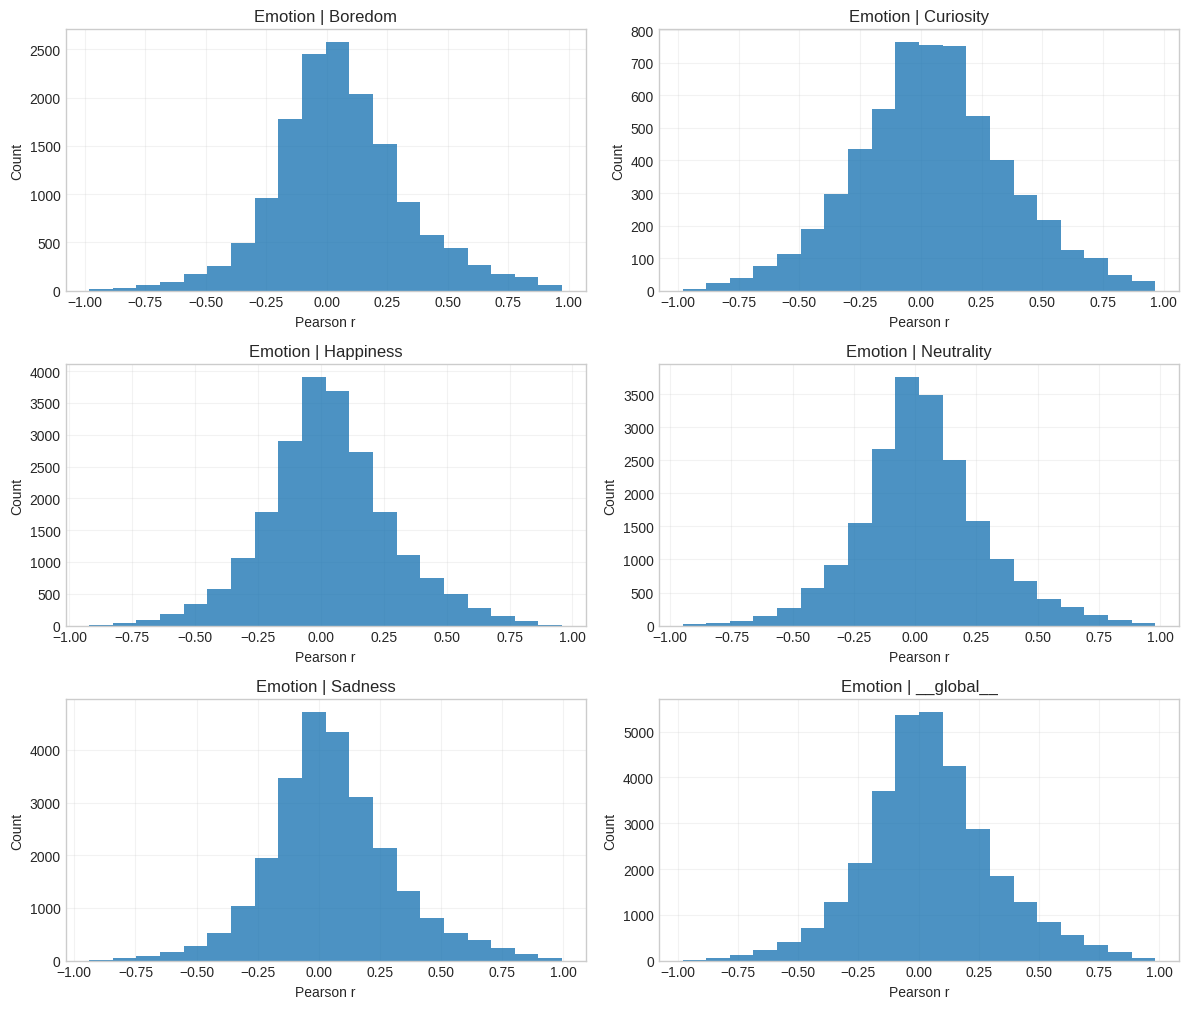

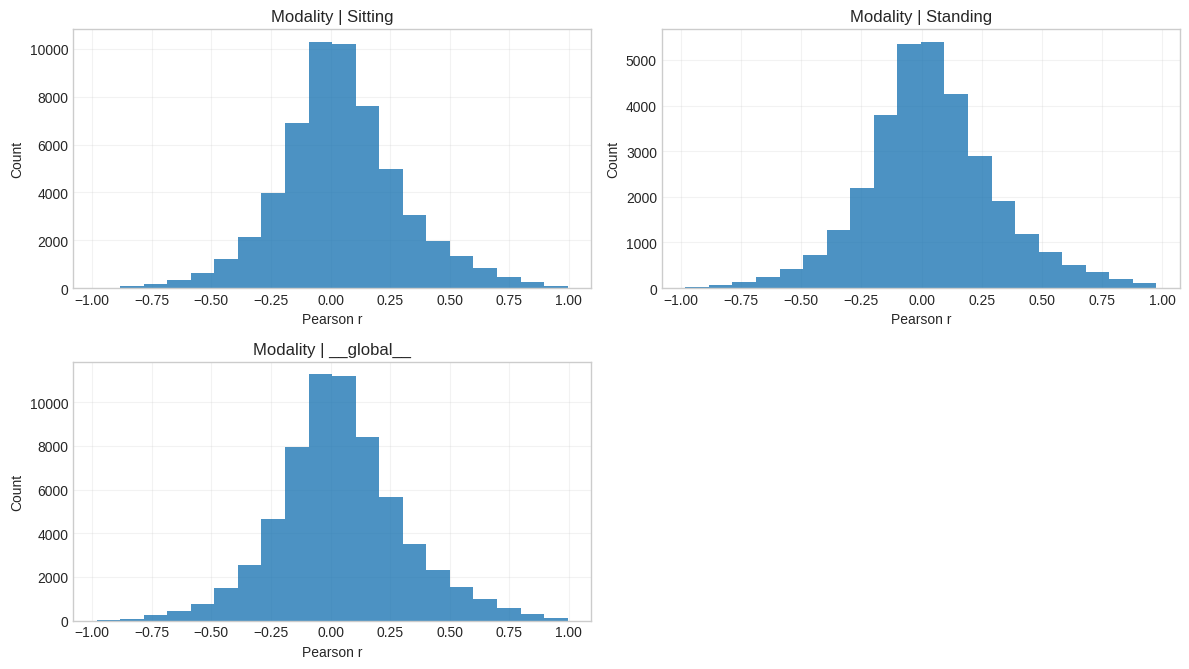

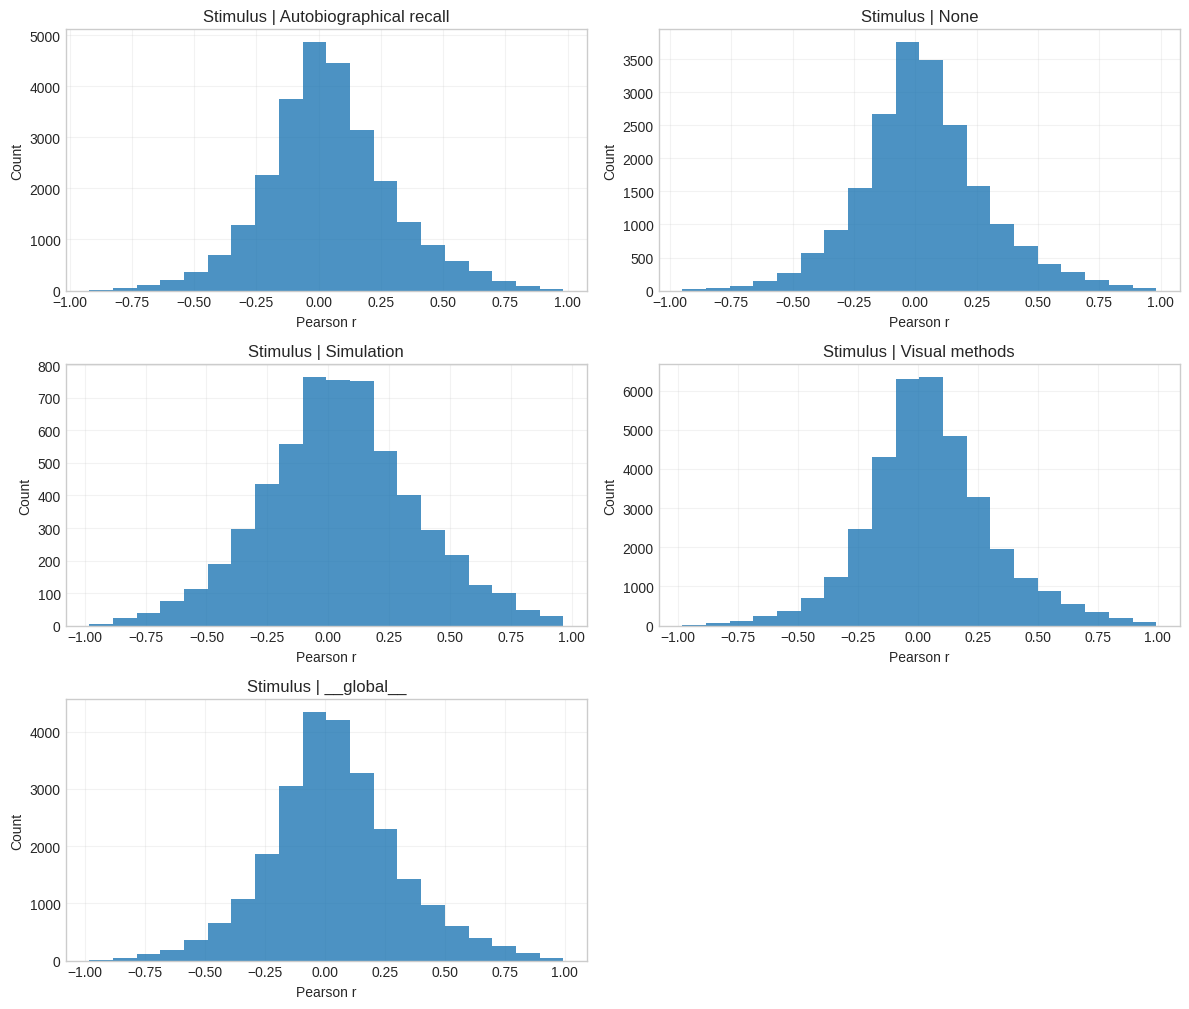

In [26]:
RESULT_MIXED = run_pose_experiment("mixed_pose", CAPTURES_MIXED)

---
## Comparison across experiments

### Overall metrics (class = "all")

In [27]:
METRIC_COLS = [
    "cfid_mean", "js_mean", "mmd_mean",
    "dtw_rtr", "dtw_rts", "dtw_sts",
    "ds_mean", "ps_mean", "pearson_mean",
]

all_results = [RESULT_REAL, RESULT_SYNTHETIC, RESULT_MIXED]

frames = []
for exp in all_results:
    df = exp["result"]["results_df"].copy()
    df.insert(0, "pose_experiment", exp["label"])
    frames.append(df)

COMBINED_DF = pd.concat(frames, ignore_index=True)

overall_df = COMBINED_DF[COMBINED_DF["class_category"] == "overall"].copy()
available_cols = [c for c in METRIC_COLS if c in overall_df.columns]
display(overall_df[["pose_experiment", "class_category", "class_value"] + available_cols])

,pose_experiment,class_category,class_value,cfid_mean,js_mean,mmd_mean,dtw_rtr,dtw_rts,dtw_sts,ds_mean,ps_mean,pearson_mean
0,real_pose,overall,all,2.275767,0.196296,0.083455,7.925055,2.518085,7.499591,0.644658,0.907684,0.036627
15,synthetic_pose,overall,all,2.443909,0.223794,0.081454,7.856637,2.233869,7.662770,0.997806,0.929895,0.048717
30,mixed_pose,overall,all,1.509434,0.199530,0.074093,8.093262,2.642429,7.630563,0.898424,0.934532,0.043384


### Pivot: metric × pose_experiment (overall)

In [28]:
available_cols = [c for c in METRIC_COLS if c in overall_df.columns]
pivot = (
    overall_df
    .set_index("pose_experiment")[available_cols]
    .T
    .rename_axis("metric")
    .reset_index()
)
display(pivot)

pose_experiment,metric,real_pose,synthetic_pose,mixed_pose
0,cfid_mean,2.275767,2.443909,1.509434
1,js_mean,0.196296,0.223794,0.199530
2,mmd_mean,0.083455,0.081454,0.074093
3,dtw_rtr,7.925055,7.856637,8.093262
4,dtw_rts,2.518085,2.233869,2.642429
5,dtw_sts,7.499591,7.662770,7.630563
6,ds_mean,0.644658,0.997806,0.898424
7,ps_mean,0.907684,0.929895,0.934532
8,pearson_mean,0.036627,0.048717,0.043384


### Per-class metrics (emotion / modality / stimulus)

In [29]:
for category in ("emotion", "modality", "stimulus"):
    subset = COMBINED_DF[COMBINED_DF["class_category"] == category].copy()
    if subset.empty:
        continue
    available_cols = [c for c in METRIC_COLS if c in subset.columns]
    display(Markdown(f"#### {category.capitalize()}"))
    display(
        subset[["pose_experiment", "class_value"] + available_cols]
        .sort_values(["class_value", "pose_experiment"])
        .reset_index(drop=True)
    )

#### Emotion

,pose_experiment,class_value,cfid_mean,js_mean,mmd_mean,dtw_rtr,dtw_rts,dtw_sts,ds_mean,ps_mean,pearson_mean
0,mixed_pose,Boredom,0.862390,0.324466,0.078804,6.786169,1.847152,5.972296,0.882947,0.933817,0.058459
1,real_pose,Boredom,1.149121,0.306253,0.124261,6.989258,2.379647,6.007032,0.612555,-1.769342,0.051946
2,synthetic_pose,Boredom,3.186635,0.381136,0.092559,6.712343,1.659473,5.614454,0.999432,0.928050,0.056131
3,mixed_pose,Curiosity,3.509336,0.373890,0.190569,6.333703,3.417692,5.733508,0.952383,0.744769,0.047402
4,real_pose,Curiosity,14.583347,0.373629,0.367990,5.648027,4.163992,3.678308,0.601393,-7.918238,0.056227
5,synthetic_pose,Curiosity,6.406730,0.525335,0.203731,6.249088,3.958543,6.298739,0.998684,0.737052,0.045727
6,mixed_pose,Happiness,2.316912,0.262509,0.149676,7.860154,3.712370,7.452922,0.905076,0.899083,0.031035
7,real_pose,Happiness,5.067278,0.307269,0.209259,7.137849,3.351846,5.278559,0.570671,-4.980125,0.002185
8,synthetic_pose,Happiness,4.472910,0.351402,0.183910,7.872166,3.793267,6.580096,0.997644,0.930338,0.043149
9,mixed_pose,Neutrality,2.299583,0.260681,0.101448,7.940009,2.637044,7.571423,0.864035,0.919429,0.031025


#### Modality

,pose_experiment,class_value,cfid_mean,js_mean,mmd_mean,dtw_rtr,dtw_rts,dtw_sts,ds_mean,ps_mean,pearson_mean
0,mixed_pose,Sitting,1.652648,0.213492,0.066284,7.902057,2.458590,8.662784,0.884953,0.951758,0.044948
1,real_pose,Sitting,2.148345,0.218090,0.079705,8.139462,2.809979,6.701328,0.609568,0.881086,0.022664
2,synthetic_pose,Sitting,2.980446,0.248213,0.076061,7.910466,2.672775,8.316814,0.997642,0.947582,0.057050
3,mixed_pose,Standing,1.414604,0.241637,0.115624,6.082218,2.588881,6.065106,0.910582,0.886646,0.040601
4,real_pose,Standing,3.400568,0.220098,0.131115,5.694399,2.337688,5.734011,0.626944,0.674568,0.057609
5,synthetic_pose,Standing,2.384733,0.311086,0.133355,6.132614,2.499353,5.938911,0.998367,0.891836,0.033875
6,mixed_pose,__global__,1.464947,0.201189,0.079699,8.364293,2.244819,7.536177,0.897087,0.931287,0.042781
7,real_pose,__global__,2.432579,0.196552,0.091946,7.635190,2.183916,7.164592,0.616569,0.900057,0.040305
8,synthetic_pose,__global__,2.189390,0.229975,0.088761,7.606414,2.360686,7.994276,0.993686,0.922895,0.045091


#### Stimulus

,pose_experiment,class_value,cfid_mean,js_mean,mmd_mean,dtw_rtr,dtw_rts,dtw_sts,ds_mean,ps_mean,pearson_mean
0,mixed_pose,Autobiographical recall,1.722460,0.253540,0.126963,7.139498,3.496236,6.299116,0.899664,0.909982,0.040981
1,real_pose,Autobiographical recall,3.063568,0.288852,0.165533,7.251835,2.911373,5.870379,0.563439,-3.877777,0.038176
2,synthetic_pose,Autobiographical recall,3.111932,0.342653,0.164368,6.943448,2.550525,6.900611,0.997812,0.948136,0.044429
3,mixed_pose,None,2.317601,0.261712,0.101426,7.263554,2.023625,7.273469,0.875565,0.919429,0.031025
4,real_pose,None,1.693996,0.235985,0.079226,6.060279,2.016066,6.258685,0.606483,-10.684643,0.030711
5,synthetic_pose,None,4.810452,0.333352,0.128794,7.837540,2.663671,7.860470,0.999107,0.908702,0.037490
6,mixed_pose,Simulation,3.475719,0.374229,0.191415,5.955263,3.596108,6.218962,0.923363,0.744769,0.047402
7,real_pose,Simulation,14.635107,0.373618,0.367834,5.787903,4.149570,3.728226,0.623981,-7.918238,0.056227
8,synthetic_pose,Simulation,6.366471,0.525284,0.203109,5.928029,3.577242,6.368529,0.998684,0.737052,0.045727
9,mixed_pose,Visual methods,1.415866,0.237531,0.062023,7.582545,2.283155,6.915340,0.859272,0.955097,0.051583


### Bar charts — overall metrics by experiment

In [ ]:
available_cols = [c for c in METRIC_COLS if c in overall_df.columns]
experiments    = [exp["label"] for exp in all_results]
colors         = ["#4C72B0", "#DD8452", "#55A868"]

METRIC_DISPLAY_NAMES = {
    "cfid_mean": "Context-FID",
    "mmd_mean":  "MMD",
    "js_mean":   "JS",
}

n_metrics = len(available_cols)
n_cols    = 3
n_rows    = (n_metrics + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes_flat = axes.flat

for ax, metric in zip(axes_flat, available_cols):
    values = []
    for exp_label in experiments:
        row = overall_df[overall_df["pose_experiment"] == exp_label]
        values.append(float(row[metric].iloc[0]) if not row.empty and metric in row.columns else float("nan"))
    bars = ax.bar(experiments, values, color=colors[: len(experiments)])
    ax.set_title(METRIC_DISPLAY_NAMES.get(metric, metric), fontsize=11)
    ax.tick_params(axis="x", rotation=15)
    for bar, val in zip(bars, values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{val:.3f}",
                    ha="center", va="bottom", fontsize=8)

for ax in list(axes_flat)[n_metrics:]:
    ax.set_visible(False)

fig.suptitle("Similarity protocol — overall metrics by pose experiment", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### Spider (radar) charts — distribution metrics by experiment

Each figure shows one metric. Rows = experiments, columns = class categories (emotion / modality / stimulus).
All experiments share the same radial scale per class category so shapes are directly comparable.

Saved: /home/henriquesouza/POSE2IMU-Framework/outputs/similarity_pdf/spider_cfid_js_mmd.pdf


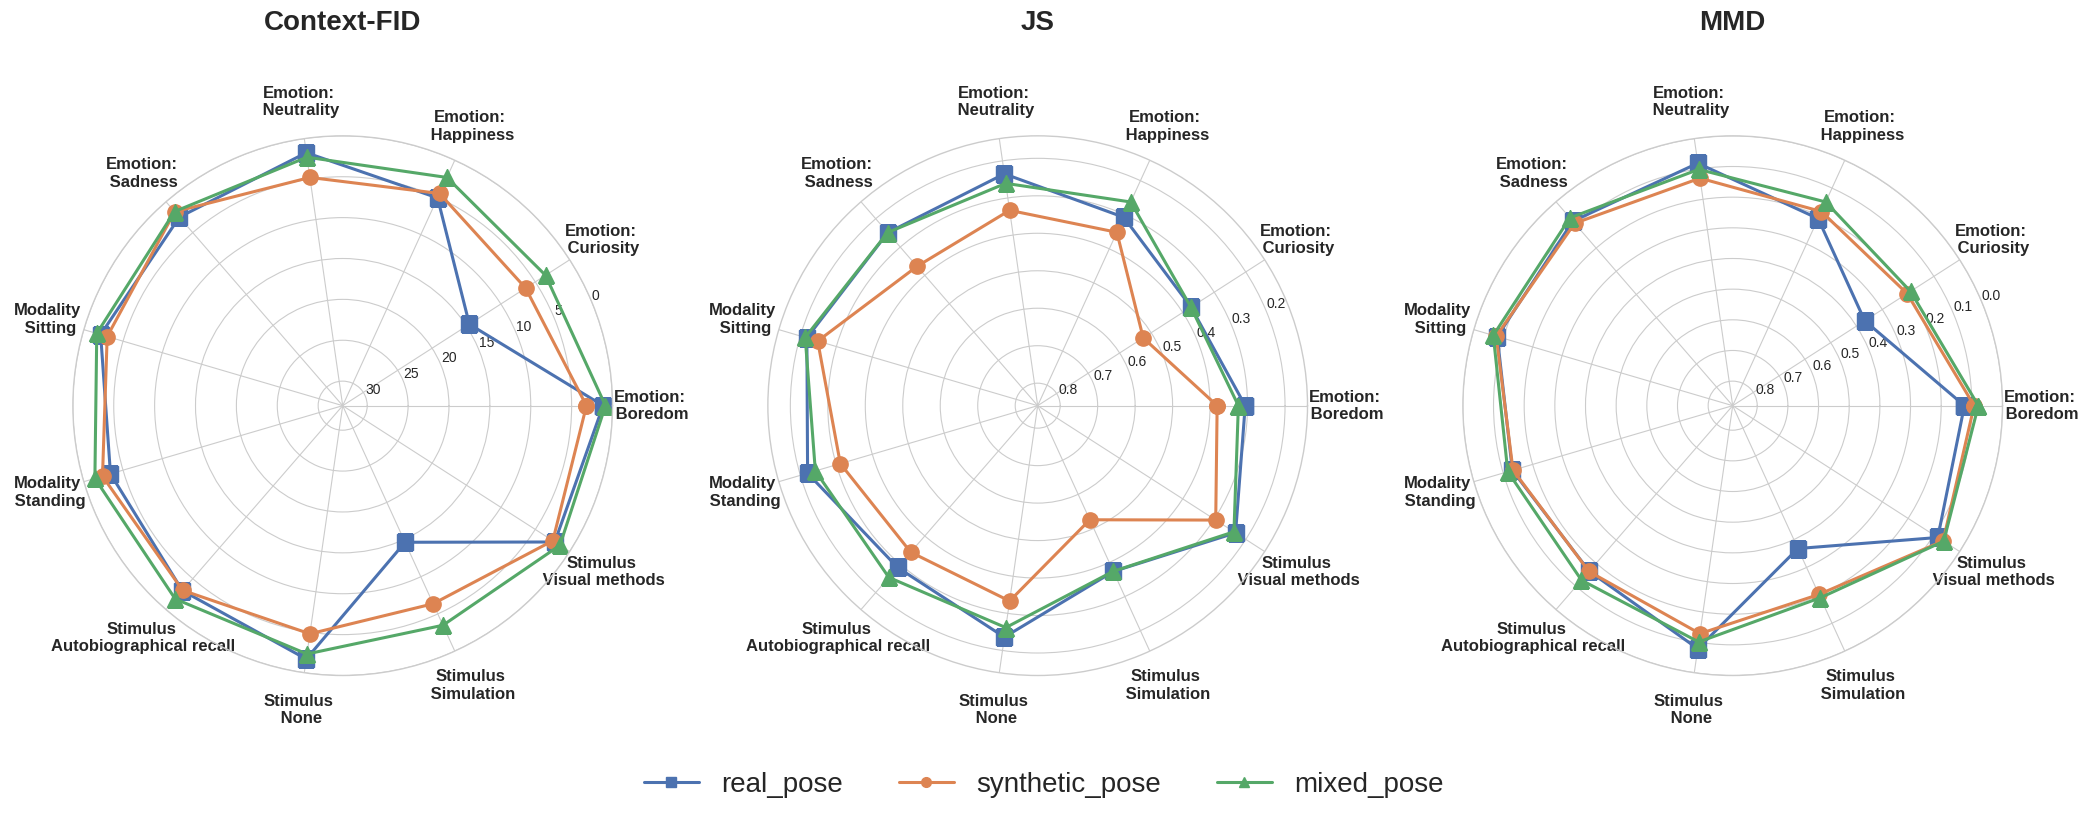

In [60]:
import math
from evaluation.similarity_protocol import CLASS_COLUMNS

SIMILARITY_PDF_DIR = PROJECT_ROOT / "outputs" / "similarity_pdf"
SIMILARITY_PDF_DIR.mkdir(parents=True, exist_ok=True)

EXP_COLORS  = ["#4C72B0", "#DD8452", "#55A868"]
EXP_MARKERS = ["s", "o", "^"]

SPIDER_METRICS = [m for m in (
    "cfid_mean",
    "js_mean",
    "mmd_mean",
    ) if m in COMBINED_DF.columns]

INVERTED_METRICS = {"cfid_mean", "js_mean", "mmd_mean"}

METRIC_SCALE = {
    "cfid_mean": (0, 30),
    "js_mean":   (.2, .8),
    "mmd_mean":  (0, 0.8),
}

METRIC_DISPLAY_NAMES = {
    "cfid_mean": "Context-FID",
    "mmd_mean":  "MMD",
    "js_mean":   "JS",
}

CATEGORY_PREFIX = {"emotion": "Emotion:\n", "modality": "Modality\n", "stimulus": "Stimulus\n"}

# --- build combined label list (shared across all metrics) ---
combined_labels = []
label_to_cat_val = {}

for category in CLASS_COLUMNS:
    label_sets = []
    for exp in all_results:
        sub = exp["result"]["results_df"]
        sub = sub[
            (sub["class_category"].astype(str) == category)
            & (sub["class_value"].astype(str) != "__global__")
        ]
        label_sets.append(set(sub["class_value"].astype(str).tolist()))
    class_labels = sorted(set.intersection(*label_sets) if label_sets else set())
    prefix = CATEGORY_PREFIX.get(category, category[:3])
    for lbl in class_labels:
        display_label = f"{prefix} {lbl}"
        combined_labels.append(display_label)
        label_to_cat_val[display_label] = (category, lbl)

n = len(combined_labels)
angles = np.linspace(0.0, 2.0 * np.pi, n, endpoint=False)
closed_angles = np.concatenate([angles, angles[:1]])

fig, axes = plt.subplots(
    1, len(SPIDER_METRICS),
    figsize=(7 * len(SPIDER_METRICS), 7),
    subplot_kw={"projection": "polar"},
)
if len(SPIDER_METRICS) == 1:
    axes = [axes]

for ax, metric_col in zip(axes, SPIDER_METRICS):
    invert = metric_col in INVERTED_METRICS

    # compute scale for this metric
    all_vals = []
    for display_label in combined_labels:
        category, class_val = label_to_cat_val[display_label]
        for exp in all_results:
            sub = exp["result"]["results_df"]
            row = sub[
                (sub["class_category"].astype(str) == category)
                & (sub["class_value"].astype(str) == class_val)
            ]
            if not row.empty and metric_col in row.columns:
                all_vals.extend(pd.to_numeric(row[metric_col], errors="coerce").dropna().tolist())

    if not all_vals:
        ax.set_visible(False)
        continue

    spec = METRIC_SCALE.get(metric_col, (None, None))
    fixed_vmin, fixed_vmax = spec
    vmin = fixed_vmin if fixed_vmin is not None else min(all_vals)
    vmax = fixed_vmax if fixed_vmax is not None else max(all_vals)

    if math.isclose(vmin, vmax):
        pad = max(1e-6, abs(vmax) * 0.05, 0.05)
        vmin -= pad; vmax += pad
    elif not invert and fixed_vmin is None and vmin > 0:
        vmin = 0.0

    for exp, color, marker in zip(all_results, EXP_COLORS, EXP_MARKERS):
        raw_vals = []
        for display_label in combined_labels:
            category, class_val = label_to_cat_val[display_label]
            sub = exp["result"]["results_df"]
            row = sub[
                (sub["class_category"].astype(str) == category)
                & (sub["class_value"].astype(str) == class_val)
            ]
            if not row.empty and metric_col in row.columns:
                raw_vals.append(pd.to_numeric(row[metric_col], errors="coerce").iloc[0])
            else:
                raw_vals.append(float("nan"))

        raw = np.array(raw_vals, dtype=float)
        if not np.isfinite(raw).any():
            continue

        raw = np.where(~np.isfinite(raw), vmin, raw)
        closed_values = np.concatenate([raw, raw[:1]])
        ax.plot(
            closed_angles, closed_values,
            linewidth=2.2, color=color, label=exp["label"],
            marker=marker, markersize=11, markerfacecolor=color,
        )

    ax.set_xticks(angles)
    ax.set_xticklabels(combined_labels, size=12, fontweight="bold")
    ax.tick_params(axis="x", pad=20)
    if invert:
        pad = (vmax - vmin) * 0.1
        ax.set_ylim(vmax + pad, max(0.0, vmin - pad))
    else:
        ax.set_ylim(vmin, vmax)
    ax.set_title(METRIC_DISPLAY_NAMES.get(metric_col, metric_col), fontsize=20, fontweight="bold", pad=40)

handles = [
    plt.Line2D([0], [0], color=c, linewidth=2.2, marker=m, markersize=7, label=exp["label"])
    for exp, c, m in zip(all_results, EXP_COLORS, EXP_MARKERS)
]
fig.legend(handles=handles, loc="lower center", ncol=len(all_results), bbox_to_anchor=(0.5, -0.15), fontsize=20)
plt.tight_layout()
fig.savefig(SIMILARITY_PDF_DIR / "spider_cfid_js_mmd.pdf", bbox_inches="tight")
print(f"Saved: {SIMILARITY_PDF_DIR / 'spider_cfid_js_mmd.pdf'}")
plt.show()

### DTW curves by experiment

Saved: /home/henriquesouza/POSE2IMU-Framework/outputs/similarity_pdf/dtw_emotion.pdf


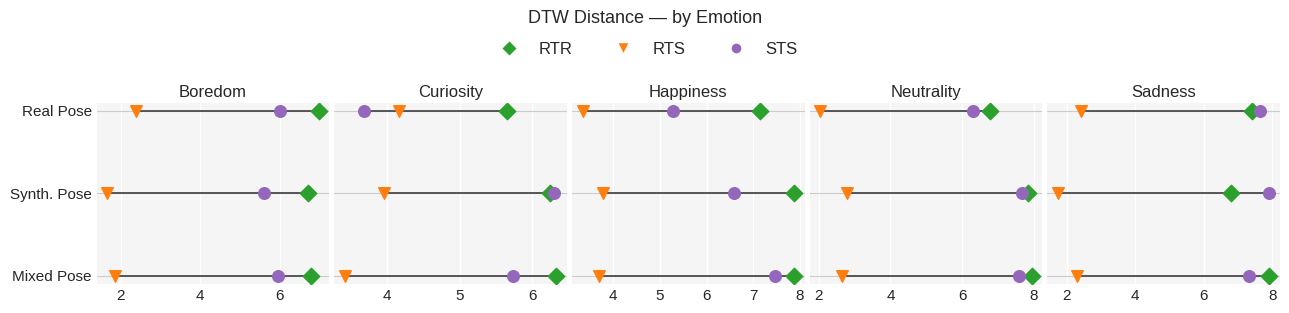

Saved: /home/henriquesouza/POSE2IMU-Framework/outputs/similarity_pdf/dtw_modality.pdf


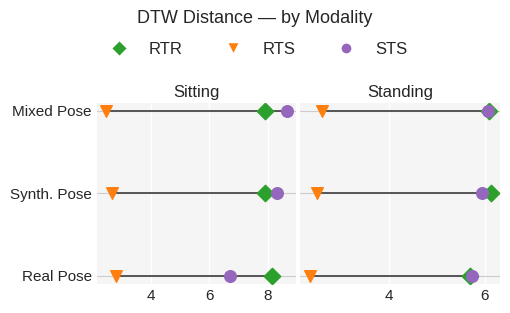

Saved: /home/henriquesouza/POSE2IMU-Framework/outputs/similarity_pdf/dtw_stimulus.pdf


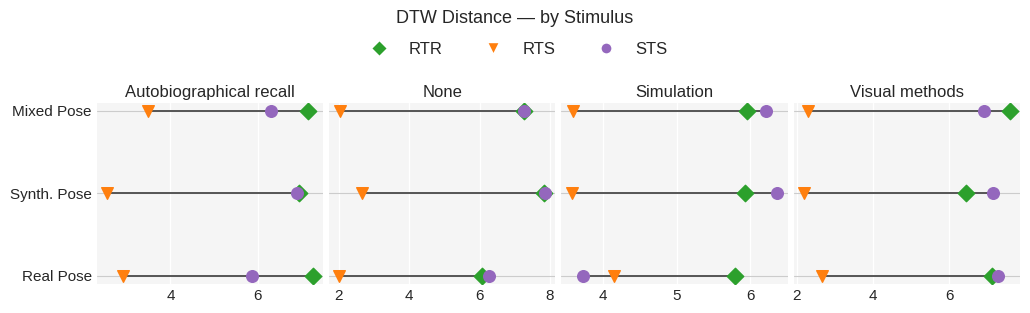

In [32]:

from matplotlib.lines import Line2D

def plot_dtw_paper_style(
    combined_df: pd.DataFrame,
    category: str = "emotion",
    experiments: list[str] | None = None,
    exp_labels: dict[str, str] | None = None,
    figsize_per_class: tuple[float, float] = (2.6, 2.8),
    save_path: str | None = None,
):
    """
    DTW dot-range plot in the style of Figure 4 from the IMUEval paper.
    Each class gets one sub-panel. Rows = experiments. Three markers per row:
      RTR (green diamond), RTS (orange downward triangle), STS (purple circle).
    A horizontal line spans [min, max] of the three values.
    """
    if experiments is None:
        experiments = combined_df["pose_experiment"].unique().tolist()
    if exp_labels is None:
        exp_labels = {e: e.replace("_", " ").title() for e in experiments}

    subset = combined_df[
        (combined_df["class_category"] == category) &
        (combined_df["class_value"] != "__global__") &
        (combined_df["pose_experiment"].isin(experiments))
    ].copy()

    classes = sorted(subset["class_value"].unique())
    n = len(classes)
    if n == 0:
        print(f"No classes found for category={category!r}")
        return

    fig_w = figsize_per_class[0] * n
    fig_h = figsize_per_class[1]
    fig, axes = plt.subplots(1, n, figsize=(fig_w, fig_h), sharey=True)
    if n == 1:
        axes = [axes]

    RTR_COLOR = "#2ca02c"
    RTS_COLOR = "#ff7f0e"
    STS_COLOR = "#9467bd"
    MARKER_SIZE = 70
    LINE_COLOR  = "#555555"
    LINE_WIDTH  = 1.4

    for ax, cls in zip(axes, classes):
        cls_data = subset[subset["class_value"] == cls]

        for y_pos, exp in enumerate(experiments):
            row = cls_data[cls_data["pose_experiment"] == exp]
            if row.empty:
                continue

            rtr = float(row["dtw_rtr"].iloc[0])
            rts = float(row["dtw_rts"].iloc[0])
            sts = float(row["dtw_sts"].iloc[0])

            x_min = min(rtr, rts, sts)
            x_max = max(rtr, rts, sts)

            ax.plot([x_min, x_max], [y_pos, y_pos],
                    color=LINE_COLOR, linewidth=LINE_WIDTH, zorder=3, solid_capstyle="round")

            ax.scatter([rtr], [y_pos], marker="D", color=RTR_COLOR, s=MARKER_SIZE, zorder=5)
            ax.scatter([rts], [y_pos], marker="v", color=RTS_COLOR, s=MARKER_SIZE, zorder=5)
            ax.scatter([sts], [y_pos], marker="o", color=STS_COLOR,  s=MARKER_SIZE, zorder=5)

        ax.set_title(cls, fontsize=12, pad=4)
        ax.set_yticks(range(len(experiments)))
        ax.set_yticklabels(
            [exp_labels.get(e, e) for e in experiments],
            fontsize=11,
        )
        ax.invert_yaxis()
        ax.tick_params(axis="x", labelsize=11)
        ax.set_facecolor("#f5f5f5")
        ax.grid(axis="x", color="white", linewidth=1.0, zorder=0)
        for spine in ax.spines.values():
            spine.set_visible(False)

    legend_handles = [
        Line2D([0], [0], marker="D", color="w", markerfacecolor=RTR_COLOR, markersize=8, label="RTR"),
        Line2D([0], [0], marker="v", color="w", markerfacecolor=RTS_COLOR, markersize=8, label="RTS"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor=STS_COLOR,  markersize=8, label="STS"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, 1.04),
        fontsize=12,
        frameon=False,
    )

    fig.suptitle(f"DTW Distance — by {category.capitalize()}", fontsize=13, y=1.10)
    plt.tight_layout(w_pad=0.3)

    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
        print(f"Saved: {save_path}")

    plt.show()
    return fig


# --- run for all three class categories ---
EXP_LABELS = {
    "real_pose":      "Real Pose",
    "synthetic_pose": "Synth. Pose",
    "mixed_pose":     "Mixed Pose",
}

for cat in ("emotion", "modality", "stimulus"):
    plot_dtw_paper_style(
        COMBINED_DF, category=cat, exp_labels=EXP_LABELS,
        save_path=str(SIMILARITY_PDF_DIR / f"dtw_{cat}.pdf"),
    )


### Raw protocol records (first 3 per experiment)

In [33]:
for exp in all_results:
    display(Markdown(f"#### {exp['label']}"))
    print(json.dumps(exp["result"]["protocol_records"][:3], indent=2, ensure_ascii=False))

#### real_pose

[
  {
    "class_category": "overall",
    "class": "all",
    "metrics": {
      "cfid": {
        "mean": 2.2757673020849305,
        "std": 0.9129535118867623
      },
      "js": {
        "mean": 0.19629617379724118,
        "std": 0.012200739207391178
      },
      "mmd": {
        "mean": 0.08345536788263162,
        "std": 0.013574989318873423
      },
      "dtw": {
        "rtr": 7.925055000039949,
        "rts": 2.5180847998712945,
        "sts": 7.499591334164308
      },
      "ds": {
        "mean": 0.6446578303082027,
        "std": 0.04446549466271789
      },
      "ps": {
        "mean": 0.9076836585998536,
        "std": 0.0523625144286414
      },
      "pearson": {
        "mean": 0.036626674926467526,
        "std": 0.12122497186230059
      }
    }
  },
  {
    "class_category": "emotion",
    "class": "Boredom",
    "metrics": {
      "cfid": {
        "mean": 1.1491211044310954,
        "std": 0.16084878290785815
      },
      "js": {
        "mean": 0.306252

#### synthetic_pose

[
  {
    "class_category": "overall",
    "class": "all",
    "metrics": {
      "cfid": {
        "mean": 2.4439092687804824,
        "std": 0.9282609019828124
      },
      "js": {
        "mean": 0.22379441694513827,
        "std": 0.012444442067762618
      },
      "mmd": {
        "mean": 0.08145446407627248,
        "std": 0.012639967561188266
      },
      "dtw": {
        "rtr": 7.856637011363102,
        "rts": 2.2338687774556636,
        "sts": 7.662769562120994
      },
      "ds": {
        "mean": 0.997805577689243,
        "std": 0.0011324958445313958
      },
      "ps": {
        "mean": 0.92989541888237,
        "std": 0.002347505750248451
      },
      "pearson": {
        "mean": 0.048716909500307645,
        "std": 0.08240680243544304
      }
    }
  },
  {
    "class_category": "emotion",
    "class": "Boredom",
    "metrics": {
      "cfid": {
        "mean": 3.186635442183742,
        "std": 2.673371715297162
      },
      "js": {
        "mean": 0.38113580

#### mixed_pose

[
  {
    "class_category": "overall",
    "class": "all",
    "metrics": {
      "cfid": {
        "mean": 1.509434300057475,
        "std": 0.4833186540265197
      },
      "js": {
        "mean": 0.19953035351746753,
        "std": 0.008124330389599251
      },
      "mmd": {
        "mean": 0.07409269245536623,
        "std": 0.015434122074710283
      },
      "dtw": {
        "rtr": 8.09326239020634,
        "rts": 2.6424287376864934,
        "sts": 7.630562730662145
      },
      "ds": {
        "mean": 0.8984238737112996,
        "std": 0.044338451136400135
      },
      "ps": {
        "mean": 0.9345315158367157,
        "std": 0.010935557660592248
      },
      "pearson": {
        "mean": 0.04338423299654867,
        "std": 0.09684851133567246
      }
    }
  },
  {
    "class_category": "emotion",
    "class": "Boredom",
    "metrics": {
      "cfid": {
        "mean": 0.8623899678572925,
        "std": 0.12420724087418283
      },
      "js": {
        "mean": 0.324466